# Deep Learning WCE Classification Project

**Objective:** Build and compare deep learning models to classify GI diseases from endoscopy images, handling class imbalance and comparing against a naturally balanced dataset.

**Datasets:**
- [Kvasir-Capsule](https://osf.io/dv2ag/) — imbalanced (14 classes, ~47K images)
- [KVASIR v2](https://datasets.simula.no/kvasir/) — balanced (8 classes, 1000 each)

**Models:** EfficientNetB0, MobileNetV2, ResNet101V2

---

## Kaggle Setup

In [1]:
# ---- Kaggle Notebook dataset bootstrap --------------------------------------
# This cell is a no-op when executed outside of Kaggle Notebooks.

import sys, os

IN_KAGGLE = False
try:
    import kaggle_secrets  # noqa: F401
    IN_KAGGLE = True
except ImportError:
    pass

# Fallback detection via environment variable
if not IN_KAGGLE:
    IN_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if IN_KAGGLE:
    # ---- 1. Clone repo -------------------------------------------------------
    REPO_URL = "https://github.com/highintoxic/DLMinorProject.git"  # <-- UPDATE
    REPO_DIR = "/kaggle/working/DLMinorProject"

    if not os.path.isdir(REPO_DIR):
        os.system(f"git clone {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)
    print(f"Working directory: {os.getcwd()}")

    # ---- 2. Install dependencies --------------------------------------------
    os.system("pip install -q gdown tensorflow keras pillow seaborn scikit-learn matplotlib")

    # ---- 3. Dataset paths ---------------------------------------------------
    # /kaggle/working  → persistent across sessions within the same run
    # /kaggle/input    → read-only mounted datasets (if added via "Add Data")
    DATASET_ROOT   = "/kaggle/working/data"
    CAPSULE_DEST   = os.path.join(DATASET_ROOT, "labeled-images")
    KVASIR_V2_DEST = os.path.join(DATASET_ROOT, "kvasir-dataset-v2")

    os.makedirs(CAPSULE_DEST,   exist_ok=True)
    os.makedirs(KVASIR_V2_DEST, exist_ok=True)

    # ---- Helper: smart extract ----------------------------------------------
    # Strips the zip's single top-level folder (if present) so that class
    # sub-folders land directly inside `dest_dir` instead of being double-nested.
    def smart_extract(zip_path, dest_dir):
        import zipfile, shutil
        with zipfile.ZipFile(zip_path) as zf:
            names = zf.namelist()
            top_dirs = {n.split("/")[0] for n in names if "/" in n}
            if len(top_dirs) == 1:
                prefix = top_dirs.pop() + "/"
                tmp_dir = dest_dir + "_tmp_extract"
                os.makedirs(tmp_dir, exist_ok=True)
                zf.extractall(tmp_dir)
                src = os.path.join(tmp_dir, prefix.rstrip("/"))
                for item in os.listdir(src):
                    s = os.path.join(src, item)
                    d = os.path.join(dest_dir, item)
                    if os.path.exists(d):
                        shutil.rmtree(d) if os.path.isdir(d) else os.remove(d)
                    shutil.move(s, d)
                shutil.rmtree(tmp_dir)
                print(f"Extracted (stripped prefix '{prefix}') -> {dest_dir}")
            else:
                zf.extractall(dest_dir)
                print(f"Extracted -> {dest_dir}")

    # ---- Helper: gdown download with fallback -------------------------------
    def gdown_download(gdrive_id_or_url, dest_path, fuzzy=False):
        """
        Download a file from Google Drive using gdown.
        gdrive_id_or_url: either a full share URL or just the file ID.
        """
        import gdown
        if gdrive_id_or_url.startswith("http"):
            url = gdrive_id_or_url
        else:
            url = f"https://drive.google.com/uc?id={gdrive_id_or_url}"
        print(f"Downloading from Google Drive -> {dest_path} ...")
        gdown.download(url, dest_path, quiet=False, fuzzy=fuzzy)
        if not os.path.isfile(dest_path):
            raise RuntimeError(f"gdown failed to download: {url}")
        print(f"Download complete: {dest_path}")

    # =========================================================================
    # ---- Strategy A: gdown (Google Drive) -----------------------------------
    # Share your zip files on Google Drive (anyone with link) and paste the
    # file IDs or full share URLs below.
    # =========================================================================
    USE_GDRIVE = True    # <-- set True to use Google Drive via gdown

    # How to get the ID:
    #   Right-click file in Drive → Share → Copy link
    #   Link looks like: https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
    #   Paste the full URL, or just the <FILE_ID> string.
    GDRIVE_ID_CAPSULE = "1CJ98vIg6JTcJXrMXYdqnFzbMyOB8wW9V"   # <-- UPDATE
    GDRIVE_ID_V2      = "1tgcZkO4b9I-LpxonewFXMMHiuP1WgNFc" # <-- UPDATE

    if USE_GDRIVE:
        for gdrive_ref, dest, label in [
            (GDRIVE_ID_CAPSULE, CAPSULE_DEST,   "Kvasir-Capsule"),
            (GDRIVE_ID_V2,      KVASIR_V2_DEST, "Kvasir-v2"),
        ]:
            zip_path = dest + ".zip"
            if not os.path.isfile(zip_path) and not os.listdir(dest):
                gdown_download(gdrive_ref, zip_path, fuzzy=True)
                smart_extract(zip_path, dest)
                os.remove(zip_path)
                print(f"✅ {label} ready at {dest}")
            else:
                print(f"⏭ {label} already present, skipping download.")

    # =========================================================================
    # ---- Strategy B: Kaggle "Add Data" (read-only /kaggle/input) ------------
    # Add the datasets to your notebook via the Kaggle UI (+ Add Data button).
    # They appear at /kaggle/input/<dataset-slug>/ automatically — no download
    # needed. Just point the paths here and flip USE_KAGGLE_INPUT to True.
    # =========================================================================
    USE_KAGGLE_INPUT = False   # <-- set True if datasets added via Kaggle UI

    KAGGLE_INPUT_CAPSULE = "/kaggle/input/kvasir-capsule"       # <-- UPDATE slug
    KAGGLE_INPUT_V2      = "/kaggle/input/kvasir-dataset-v2"    # <-- UPDATE slug

    if USE_KAGGLE_INPUT:
        import src.data_utils as _du
        from pathlib import Path
        _du.DATA_DIR      = Path(KAGGLE_INPUT_CAPSULE)
        _du.KVASIR_V2_DIR = Path(KAGGLE_INPUT_V2)
        print(f"Using Kaggle-mounted datasets (read-only).")
        print(f"   Kvasir-Capsule : {_du.DATA_DIR}")
        print(f"   KVASIR v2      : {_du.KVASIR_V2_DIR}")

    # =========================================================================
    # ---- Strategy C: Direct URL (wget / urllib) ------------------------------
    # Use this for publicly accessible direct download links (not Drive).
    # =========================================================================
    USE_DIRECT_URL = False   # <-- set True for direct HTTP links

    DIRECT_URL_CAPSULE = "https://REPLACE_WITH_DIRECT_URL_TO_kvasir-capsule.zip"
    DIRECT_URL_V2      = "https://REPLACE_WITH_DIRECT_URL_TO_kvasir-dataset-v2.zip"

    if USE_DIRECT_URL:
        import urllib.request
        for url, dest in [(DIRECT_URL_CAPSULE, CAPSULE_DEST),
                          (DIRECT_URL_V2,      KVASIR_V2_DEST)]:
            zip_path = dest + ".zip"
            print(f"Downloading {url} ...")
            urllib.request.urlretrieve(url, zip_path)
            smart_extract(zip_path, dest)
            os.remove(zip_path)

    # ---- 4. Patch DATA_DIR / KVASIR_V2_DIR (for gdown / direct URL paths) ---
    if USE_GDRIVE or USE_DIRECT_URL:
        import src.data_utils as _du
        from pathlib import Path
        _du.DATA_DIR      = Path(CAPSULE_DEST)
        _du.KVASIR_V2_DIR = Path(KVASIR_V2_DEST)

    print("\n✅ Kaggle setup complete.")
    print(f"   Kvasir-Capsule : {CAPSULE_DEST}")
    print(f"   KVASIR v2      : {KVASIR_V2_DEST}")

else:
    print("Running locally – no dataset download needed.")

Cloning into '/kaggle/working/DLMinorProject'...


Working directory: /kaggle/working/DLMinorProject


Downloading...
From (original): https://drive.google.com/uc?id=1CJ98vIg6JTcJXrMXYdqnFzbMyOB8wW9V
From (redirected): https://drive.google.com/uc?id=1CJ98vIg6JTcJXrMXYdqnFzbMyOB8wW9V&confirm=t&uuid=01b44b6e-a9e2-4cfa-add5-d1e677a5b18a
To: /kaggle/working/data/labeled-images.zip
100%|██████████| 589M/589M [00:02<00:00, 212MB/s]


Download complete: /kaggle/working/data/labeled-images.zip
Extracted (stripped prefix 'labeled-images/') -> /kaggle/working/data/labeled-images
✅ Kvasir-Capsule ready at /kaggle/working/data/labeled-images


Downloading...
From (original): https://drive.google.com/uc?id=1tgcZkO4b9I-LpxonewFXMMHiuP1WgNFc
From (redirected): https://drive.google.com/uc?id=1tgcZkO4b9I-LpxonewFXMMHiuP1WgNFc&confirm=t&uuid=c9e82425-09c1-4ef8-8483-2dfb885cba3e
To: /kaggle/working/data/kvasir-dataset-v2.zip
100%|██████████| 2.49G/2.49G [00:19<00:00, 131MB/s]


Download complete: /kaggle/working/data/kvasir-dataset-v2.zip
Extracted (stripped prefix 'kvasir-dataset-v2/') -> /kaggle/working/data/kvasir-dataset-v2
✅ Kvasir-v2 ready at /kaggle/working/data/kvasir-dataset-v2

✅ Kaggle setup complete.
   Kvasir-Capsule : /kaggle/working/data/labeled-images
   KVASIR v2      : /kaggle/working/data/kvasir-dataset-v2


In [2]:
%cd notebooks

/kaggle/working/DLMinorProject/notebooks


## Setup

In [3]:
import sys
sys.path.insert(0, '..')

from src.data_utils import (
    load_image_paths, get_class_distribution, plot_class_distribution,
    load_image, DATA_DIR, KVASIR_V2_DIR
)
from src.sampling import undersample, oversample_augment, show_augmentation_samples
from src.preprocessing import preprocess_dataset
from src.models import build_model, print_model_summary, build_all_models
from src.training import compile_model, train_model, plot_training_history, plot_lr_schedule
from src.evaluation import evaluate_model, plot_confusion_matrix, build_comparison_table, display_comparison

import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')
print(f'Kvasir-Capsule dir: {DATA_DIR}')
print(f'KVASIR v2 dir:      {KVASIR_V2_DIR}')

2026-03-23 04:35:20.221216: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774240520.411446      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774240520.465385      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774240520.899968      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774240520.900005      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774240520.900008      24 computation_placer.cc:177] computation placer alr

All imports successful!
Kvasir-Capsule dir: /kaggle/working/data/labeled-images
KVASIR v2 dir:      /kaggle/working/data/kvasir-dataset-v2


---
## Step 1 — Explore Both Datasets

Load both datasets and visualize their class distributions.

In [4]:
# ── Kvasir-Capsule (imbalanced) ──
capsule_images = load_image_paths(DATA_DIR)
capsule_dist = get_class_distribution(capsule_images)

print('Kvasir-Capsule:')
print(f'  Classes: {len(capsule_dist)}')
print(f'  Total images: {sum(capsule_dist.values()):,}')
for cls, count in sorted(capsule_dist.items(), key=lambda x: -x[1]):
    print(f'    {cls:30s} → {count:>6,}')

Kvasir-Capsule:
  Classes: 14
  Total images: 47,238
    normal-clean-mucosa            → 34,338
    Ileocecal-valve                →  4,189
    reduced-mucosal-view           →  2,906
    pylorus                        →  1,529
    angiectasia                    →    866
    ulcer                          →    854
    foreign-body                   →    776
    lymphangiectasia               →    592
    erosion                        →    506
    blood-fresh                    →    446
    erythema                       →    159
    polyp                          →     55
    blood-hematin                  →     12
    ampulla-of-vater               →     10


Saved plot to ../outputs/dist_capsule_original.png


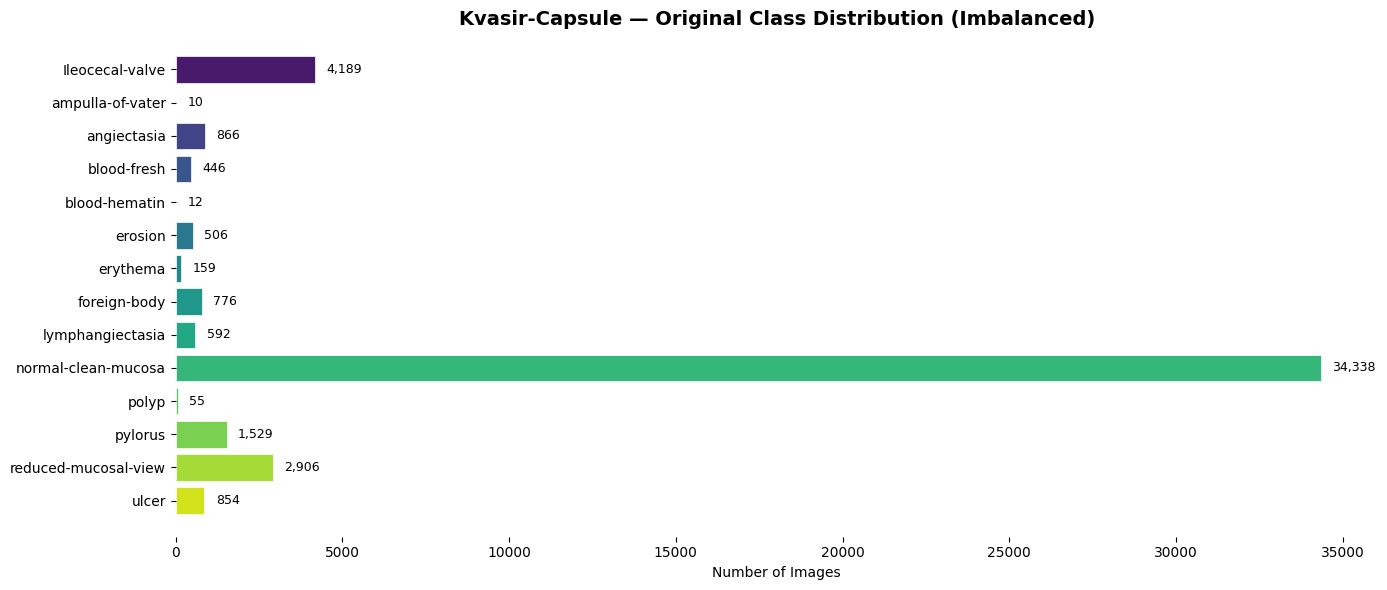

In [5]:
plot_class_distribution(
    capsule_dist,
    title='Kvasir-Capsule — Original Class Distribution (Imbalanced)',
    save_path='../outputs/dist_capsule_original.png'
)

In [6]:
# ── KVASIR v2 (balanced) ──
kvasir_v2_images = load_image_paths(KVASIR_V2_DIR)
kvasir_v2_dist = get_class_distribution(kvasir_v2_images)

print('KVASIR v2:')
print(f'  Classes: {len(kvasir_v2_dist)}')
print(f'  Total images: {sum(kvasir_v2_dist.values()):,}')
for cls, count in sorted(kvasir_v2_dist.items(), key=lambda x: -x[1]):
    print(f'    {cls:30s} → {count:>6,}')

KVASIR v2:
  Classes: 8
  Total images: 8,000
    dyed-lifted-polyps             →  1,000
    dyed-resection-margins         →  1,000
    esophagitis                    →  1,000
    normal-cecum                   →  1,000
    normal-pylorus                 →  1,000
    normal-z-line                  →  1,000
    polyps                         →  1,000
    ulcerative-colitis             →  1,000


Saved plot to ../outputs/dist_kvasir_v2.png


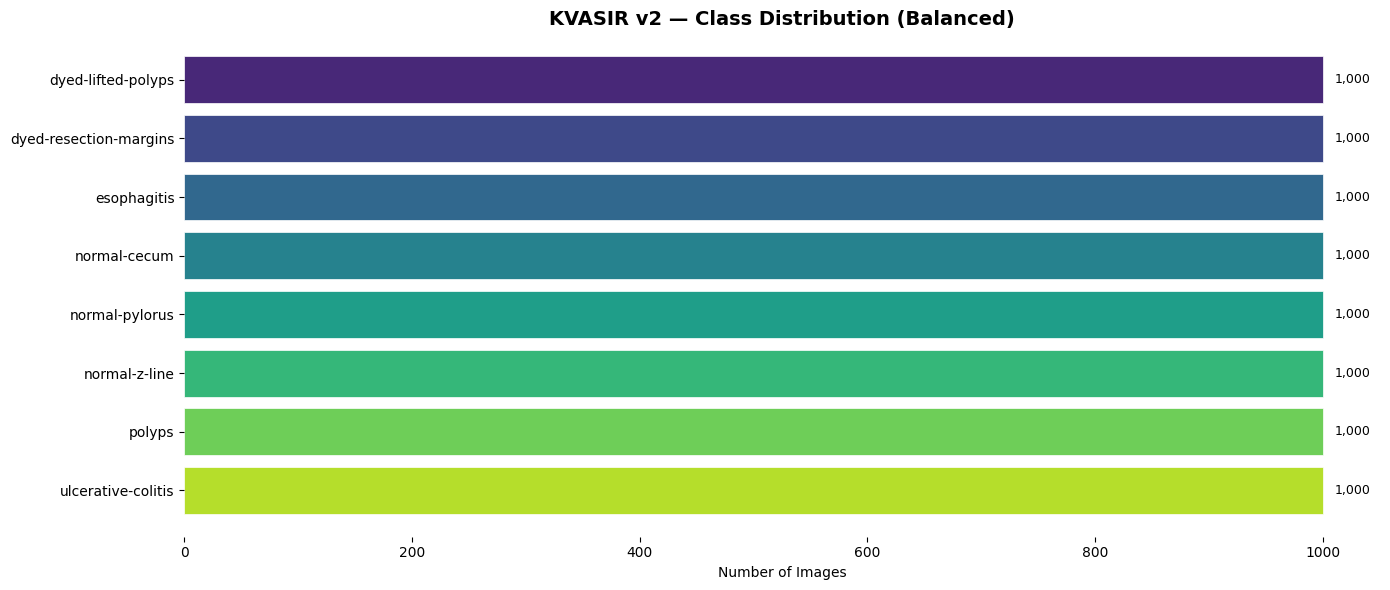

In [7]:
plot_class_distribution(
    kvasir_v2_dist,
    title='KVASIR v2 — Class Distribution (Balanced)',
    save_path='../outputs/dist_kvasir_v2.png'
)

### Analysis — Why Imbalance is Dangerous

*Write your analysis here about why class imbalance is dangerous in medical diagnosis.*

> **Key points to cover:**
> - A model predicting only the majority class gets high accuracy but misses critical conditions
> - In medical diagnosis, false negatives (missing a disease) are far worse than false positives
> - Standard accuracy is misleading for imbalanced data
> - Rare conditions (bleeding, ulcers) are clinically the most important to detect
> - Contrast Kvasir-Capsule's skew vs KVASIR v2's even distribution

---
## Step 2 — Under-Sampling Majority Classes (Kvasir-Capsule)

In [8]:
THRESHOLD = 200
undersampled = undersample(capsule_images, threshold=THRESHOLD)
under_dist = get_class_distribution(undersampled)

print(f'Original total:        {sum(capsule_dist.values()):,}')
print(f'After under-sampling:  {sum(under_dist.values()):,}')
print(f'Data removed:          {sum(capsule_dist.values()) - sum(under_dist.values()):,}')

Original total:        47,238
After under-sampling:  2,236
Data removed:          45,002


Saved plot to ../outputs/dist_capsule_undersampled.png


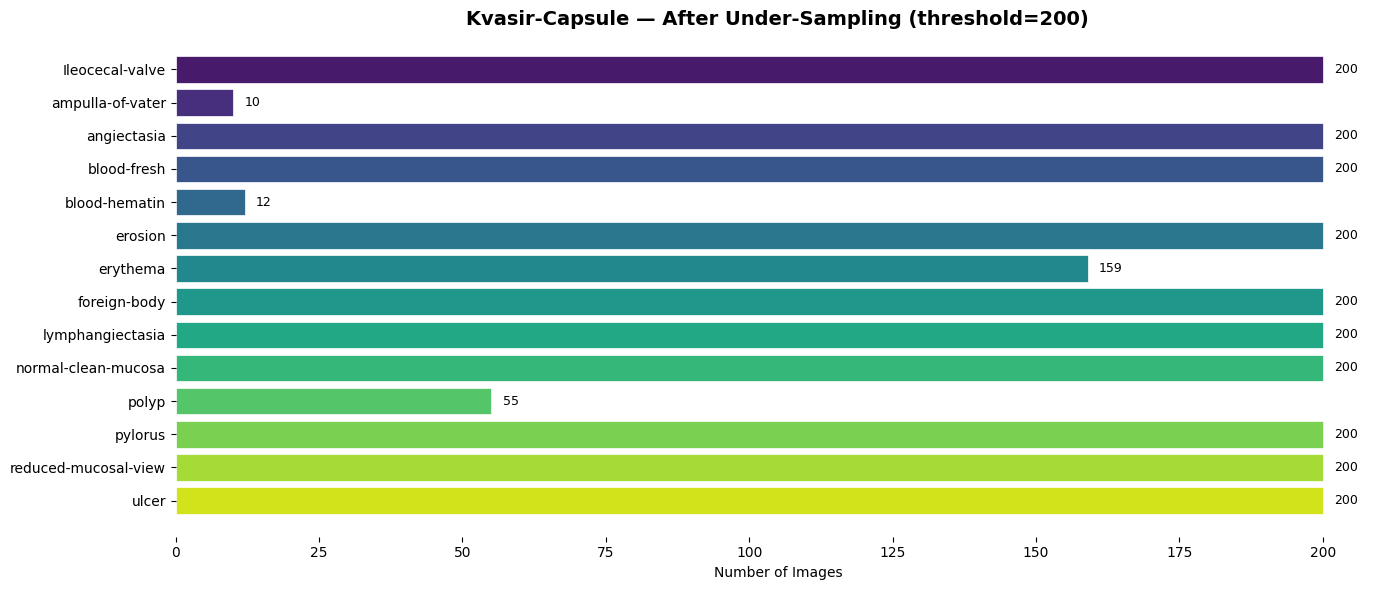

In [9]:
plot_class_distribution(
    under_dist,
    title=f'Kvasir-Capsule — After Under-Sampling (threshold={THRESHOLD})',
    save_path='../outputs/dist_capsule_undersampled.png'
)

---
## Step 3 — Over-Sampling via Augmentation (Kvasir-Capsule)

In [10]:
balanced = oversample_augment(undersampled, threshold=THRESHOLD)
balanced_dist = get_class_distribution(balanced)

print(f'After augmentation: {sum(balanced_dist.values()):,}')
for cls, count in sorted(balanced_dist.items()):
    print(f'  {cls:30s} → {count:>4}')

After augmentation: 2,800
  Ileocecal-valve                →  200
  ampulla-of-vater               →  200
  angiectasia                    →  200
  blood-fresh                    →  200
  blood-hematin                  →  200
  erosion                        →  200
  erythema                       →  200
  foreign-body                   →  200
  lymphangiectasia               →  200
  normal-clean-mucosa            →  200
  polyp                          →  200
  pylorus                        →  200
  reduced-mucosal-view           →  200
  ulcer                          →  200


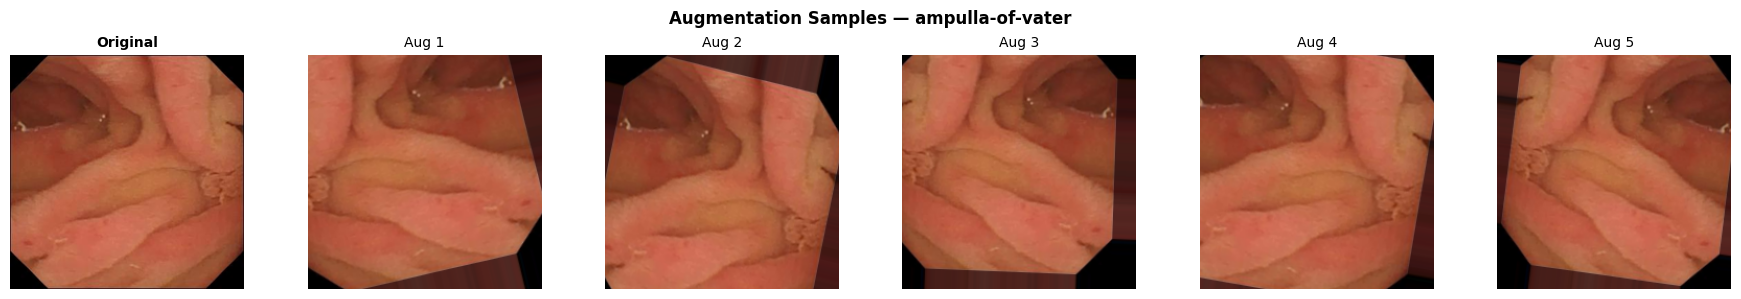

In [11]:
# Show augmentation examples from a minority class
minority_class = min(capsule_dist, key=capsule_dist.get)
sample_img = capsule_images[minority_class][0]
show_augmentation_samples(sample_img, n_samples=5, save_path='../outputs/augmentation_samples.png')

---
## Step 4 — Pre-Process Both Datasets

In [12]:
# Preprocess balanced Kvasir-Capsule (under-sampled + augmented)
print('─── Kvasir-Capsule (balanced) ───')
data_balanced = preprocess_dataset(balanced)

X_train, y_train = data_balanced['X_train'], data_balanced['y_train']
X_val,   y_val   = data_balanced['X_val'],   data_balanced['y_val']
X_test,  y_test  = data_balanced['X_test'],  data_balanced['y_test']
capsule_class_names = data_balanced['class_names']
capsule_num_classes = len(capsule_class_names)

print(f'\nClasses: {capsule_num_classes}')

─── Kvasir-Capsule (balanced) ───
Dataset splits:
  Train:       1960 samples
  Validation:   420 samples
  Test:         420 samples
  Classes:    14
  Image size: 224×224

Classes: 14


In [13]:
# Preprocess KVASIR v2
print('─── KVASIR v2 ───')
data_kvasir_v2 = preprocess_dataset(kvasir_v2_images)

kvasir_v2_class_names = data_kvasir_v2['class_names']
kvasir_v2_num_classes = len(kvasir_v2_class_names)

print(f'\nClasses: {kvasir_v2_num_classes}')

─── KVASIR v2 ───
Dataset splits:
  Train:       5600 samples
  Validation:  1200 samples
  Test:        1200 samples
  Classes:    8
  Image size: 224×224

Classes: 8


---
## Step 5 — Build 3 Transfer Learning Models

In [14]:
# Build models for Kvasir-Capsule classes
print(f'Building models for {capsule_num_classes} Kvasir-Capsule classes...')
models_capsule = build_all_models(num_classes=capsule_num_classes, dropout_rate=0.3, freeze_ratio=0.8)

Building models for 14 Kvasir-Capsule classes...
Building EfficientNetB0...


I0000 00:00:1774240550.003708      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  Model: EfficientNetB0
  Total parameters:        4,386,225
  Trainable parameters:    2,639,390
  Frozen parameters:       1,746,835
  Trainable ratio:            60.2%

Building MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  Model: MobileNetV2
  Total parameters:        2,594,638
  Trainable parameters:    1,952,654
  Frozen parameters:         641,984
  Trainable ratio:            75.3%

Building ResNet101V2...
171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

  Model: ResNet101V2
  Total parameters:       43,162,894
  Trainable parameters:   19,711,246
  Frozen parameters:      23,451,648
  Trainable ratio:            45.7%



---
## Step 6 — Learning Rate Schedules

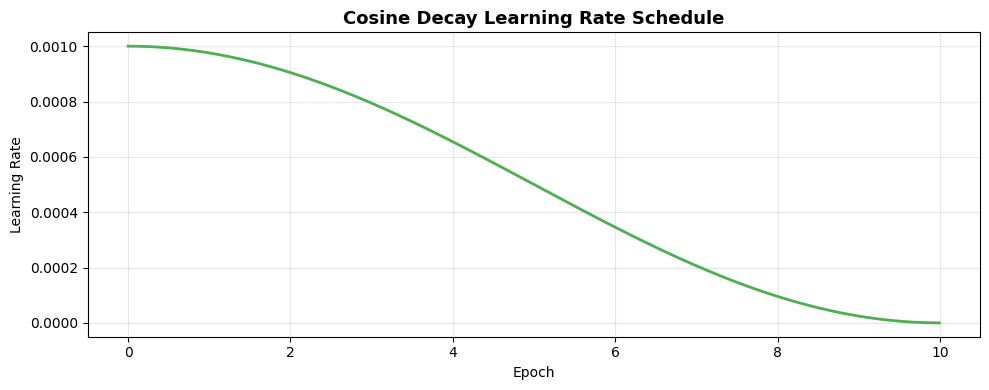

In [15]:
plot_lr_schedule(
    initial_lr=1e-3,
    total_epochs=10,
    steps_per_epoch=len(X_train) // 16,
    save_path='../outputs/lr_cosine_decay.png'
)

---
## Step 7 — Train & Compare Under 4 Scenarios

| Scenario | Dataset | Purpose |
|:---------|:--------|:--------|
| Baseline (no handling) | Raw Kvasir-Capsule | Show how bad imbalance is |
| Under-sampling only | Kvasir-Capsule trimmed | Partial fix |
| Under-sampling + Augmentation | Kvasir-Capsule balanced | Full fix |
| Naturally balanced | KVASIR v2 | Gold standard comparison |

In [16]:
# Prepare all 4 scenario datasets
data_baseline = preprocess_dataset(capsule_images)  # raw imbalanced
data_under    = preprocess_dataset(undersampled)     # under-sampled only
# data_balanced is already preprocessed above        # under-sampled + augmented
# data_kvasir_v2 is already preprocessed above       # naturally balanced

# Scenarios using Kvasir-Capsule (same num_classes)
capsule_scenarios = {
    'Baseline':                      data_baseline,
    'Under-sampling':                data_under,
    'Under-sampling + Augmentation': data_balanced,
}

print('Capsule scenarios:', list(capsule_scenarios.keys()))
print('KVASIR v2 scenario: Naturally Balanced')

Dataset splits:
  Train:      33066 samples
  Validation:  7086 samples
  Test:        7086 samples
  Classes:    14
  Image size: 224×224
Dataset splits:
  Train:       1564 samples
  Validation:   336 samples
  Test:         336 samples
  Classes:    14
  Image size: 224×224
Capsule scenarios: ['Baseline', 'Under-sampling', 'Under-sampling + Augmentation']
KVASIR v2 scenario: Naturally Balanced


---
## Training — One Cell per Scenario × Model

Each cell trains **one** model for **one** scenario, then calls `clear_session()` to free RAM before the next run.


In [17]:
# Accumulator  →  {setting: {arch: metrics_dict}}
all_results = {}


---
## S1 — Baseline (raw Kvasir-Capsule, imbalanced)


Dataset splits:
  Train:      33066 samples
  Validation:  7086 samples
  Test:        7086 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10


I0000 00:00:1774240577.232399      88 service.cc:152] XLA service 0x7c9924004870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774240577.232433      88 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774240580.458076      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774240613.333736      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2067/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6793 - loss: 1.5823
Epoch 1: val_loss improved from inf to 1.17225, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s1_baseline_efficientnetb0_best.keras
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 192s 64ms/step - accuracy: 0.6793 - loss: 1.5822 - val_accuracy: 0.7269 - val_loss: 1.1722 - learning_rate: 0.0010
Epoch 2/10
2065/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7301 - loss: 1.2016
Epoch 2: val_loss improved from 1.17225 to 1.16390, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s1_baseline_efficientnetb0_best.keras
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 50s 24ms/step - accuracy: 0.7301 - loss: 1.2016 - val_accuracy: 0.7269 - val_loss: 1.1639 - learning_rate: 0.0010
Epoch 3/10
2064/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7250 - loss: 1.1979
Epoch 3: val_loss improved from 1.16390 to 1.14406, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s1_baseline_efficientnet

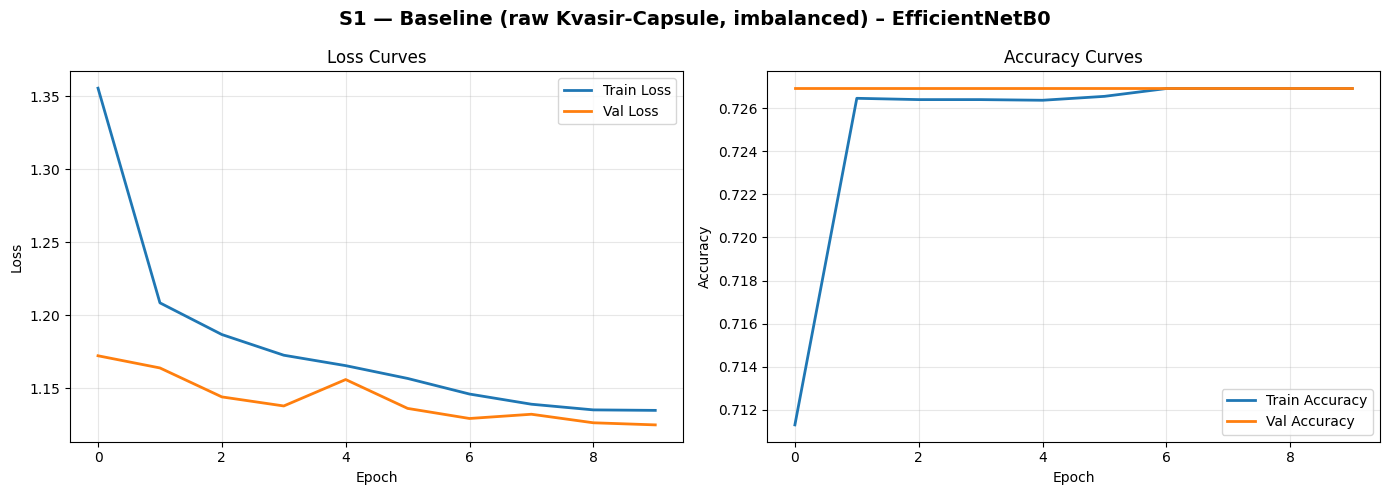


──────────────────────────────────────────────────
  EfficientNetB0 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.7269
  Precision: 0.5284
  Recall:    0.7269
  F1-score:  0.6120
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.00      0.00      0.00       628
    ampulla-of-vater       0.00      0.00      0.00         2
         angiectasia       0.00      0.00      0.00       130
         blood-fresh       0.00      0.00      0.00        67
       blood-hematin       0.00      0.00      0.00         2
             erosion       0.00      0.00      0.00        76
            erythema       0.00      0.00      0.00        24
        foreign-body       0.00      0.00      0.00       116
    lymphangiectasia       0.00      0.00      0.00        89
 normal-clean-mucosa       0.73      1.00      0.84      5151
               polyp       0.00      0.00      0.00

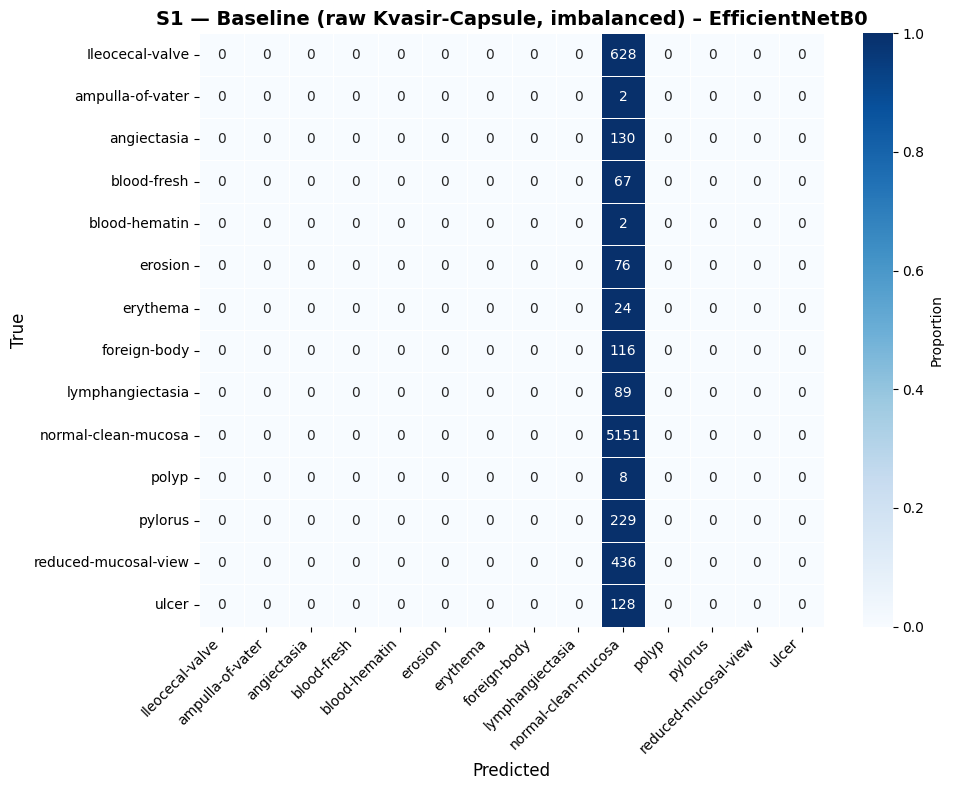

TF session cleared and garbage collected.


In [18]:
# ── S1 — Baseline (raw Kvasir-Capsule, imbalanced)  |  EfficientNetB0 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(capsule_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('EfficientNetB0', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s1_baseline/efficientnetb0').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s1_baseline_efficientnetb0',
)

# 4. Plot history
plot_training_history(
    history,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – EfficientNetB0',
    save_path='../outputs/s1_baseline/efficientnetb0/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)'] = all_results.get('S1 — Baseline (raw Kvasir-Capsule, imbalanced)', {})
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)']['EfficientNetB0'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – EfficientNetB0',
    save_path='../outputs/s1_baseline/efficientnetb0/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:      33066 samples
  Validation:  7086 samples
  Test:        7086 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7807 - loss: 0.9254
Epoch 1: val_loss improved from inf to 5.37112, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s1_baseline_mobilenetv2_best.keras
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 131s 45ms/step - accuracy: 0.7807 - loss: 0.9253 - val_accuracy: 0.1030 - val_loss: 5.3711 - learning_rate: 0.0010
Epoch 2/10
2064/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8963 - loss: 0.4014
Epoch 2: val_loss did not improve from 5.37112
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.8963 - loss: 0.4014 - val_accuracy: 0.2505 - val_loss: 5.5900 - learning_rate: 0.0010
Epoch 3/10
2065/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9180 - loss: 0.3326
Epoch 3: val_loss did not improve from 5.37112
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.

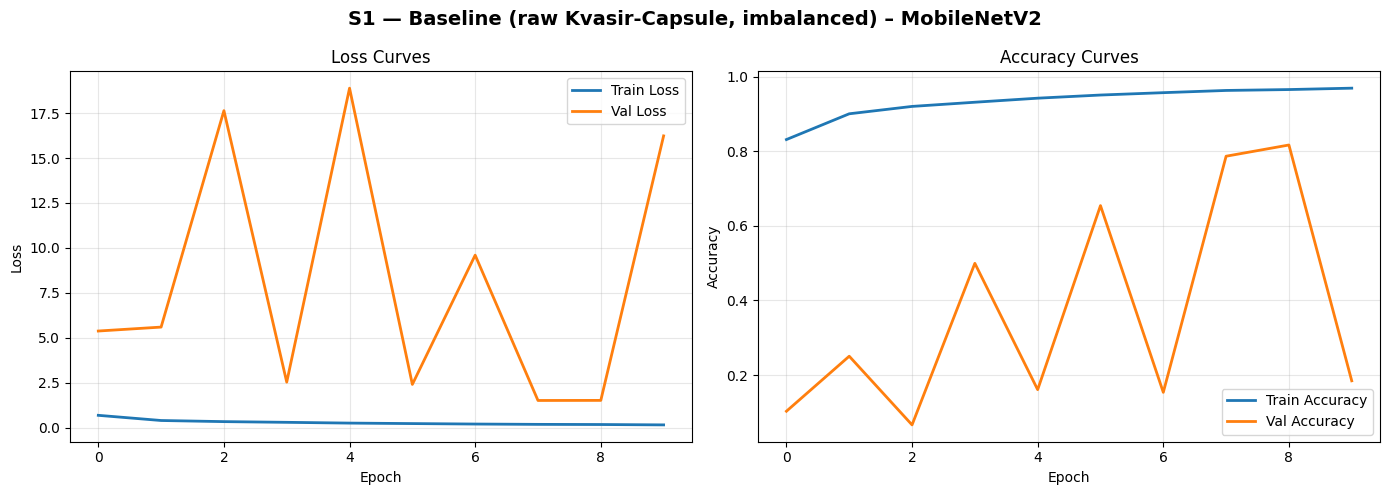


──────────────────────────────────────────────────
  MobileNetV2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.7875
  Precision: 0.8170
  Recall:    0.7875
  F1-score:  0.7607
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.56      0.35      0.43       628
    ampulla-of-vater       0.00      0.00      0.00         2
         angiectasia       0.65      0.32      0.42       130
         blood-fresh       0.16      0.93      0.27        67
       blood-hematin       0.00      0.00      0.00         2
             erosion       0.29      0.08      0.12        76
            erythema       0.71      0.21      0.32        24
        foreign-body       0.98      0.54      0.70       116
    lymphangiectasia       0.98      0.46      0.63        89
 normal-clean-mucosa       0.85      0.96      0.90      5151
               polyp       0.14      0.88      0.24   

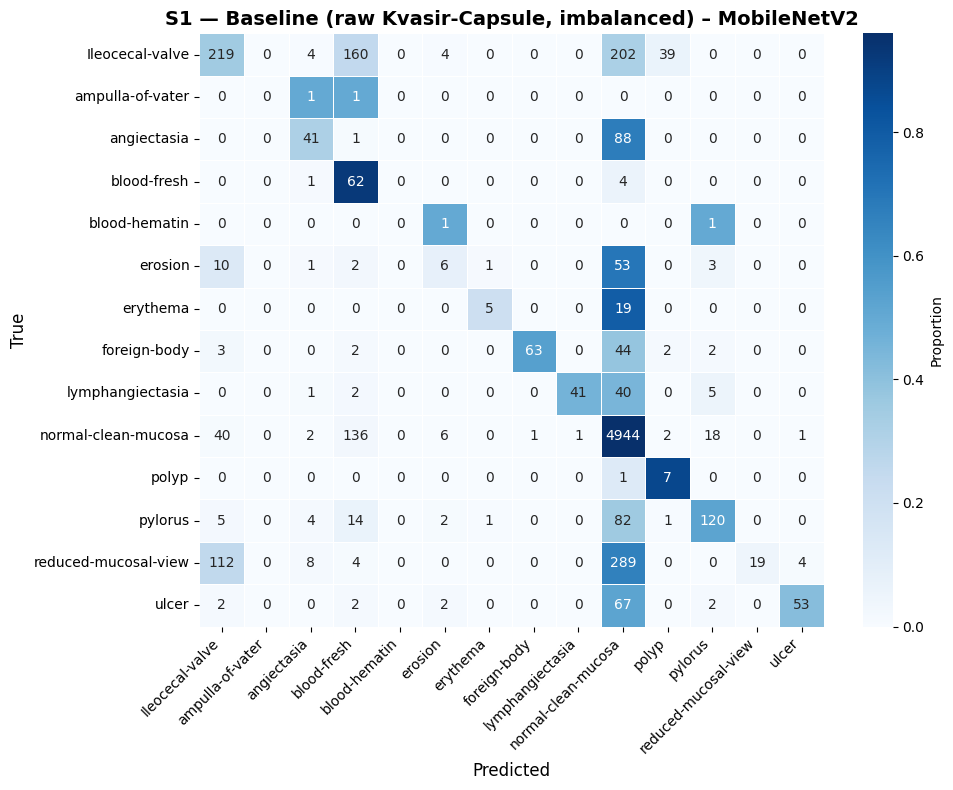

TF session cleared and garbage collected.


In [19]:
# ── S1 — Baseline (raw Kvasir-Capsule, imbalanced)  |  MobileNetV2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(capsule_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('MobileNetV2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s1_baseline/mobilenetv2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s1_baseline_mobilenetv2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – MobileNetV2',
    save_path='../outputs/s1_baseline/mobilenetv2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)'] = all_results.get('S1 — Baseline (raw Kvasir-Capsule, imbalanced)', {})
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)']['MobileNetV2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – MobileNetV2',
    save_path='../outputs/s1_baseline/mobilenetv2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:      33066 samples
  Validation:  7086 samples
  Test:        7086 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8023 - loss: 0.7987
Epoch 1: val_loss improved from inf to 3.22853, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s1_baseline_resnet101v2_best.keras
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 254s 99ms/step - accuracy: 0.8023 - loss: 0.7986 - val_accuracy: 0.7700 - val_loss: 3.2285 - learning_rate: 0.0010
Epoch 2/10
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9179 - loss: 0.3311
Epoch 2: val_loss did not improve from 3.22853
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 162s 79ms/step - accuracy: 0.9179 - loss: 0.3311 - val_accuracy: 0.7583 - val_loss: 3.2289 - learning_rate: 0.0010
Epoch 3/10
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9397 - loss: 0.2606
Epoch 3: val_loss did not improve from 3.22853
2067/2067 ━━━━━━━━━━━━━━━━━━━━ 163s 79ms/step - accuracy: 

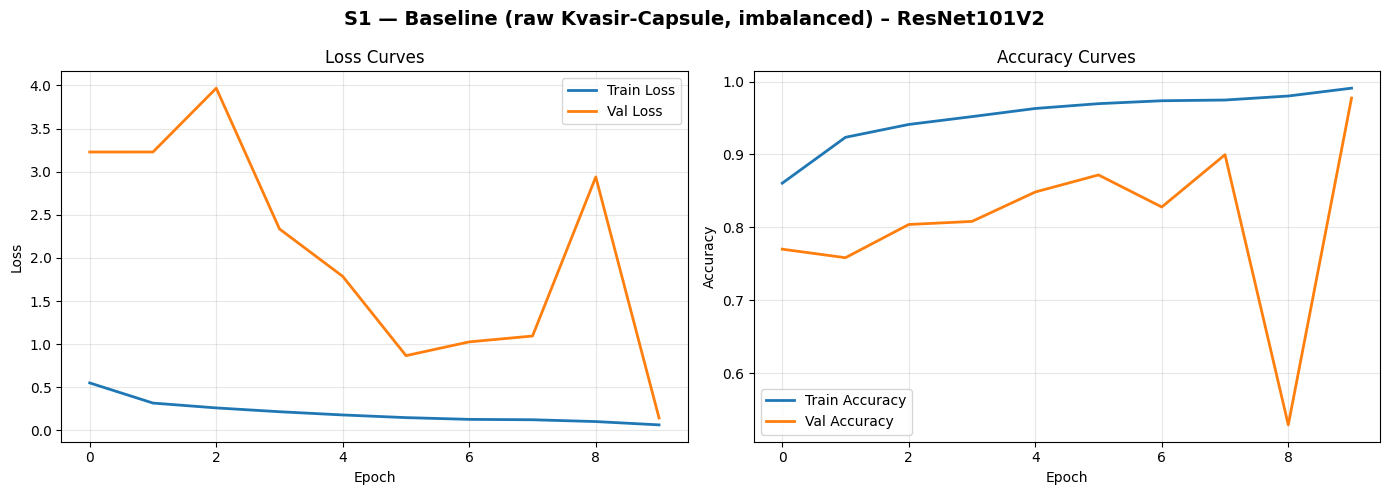


──────────────────────────────────────────────────
  ResNet101V2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.9759
  Precision: 0.9756
  Recall:    0.9759
  F1-score:  0.9749
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.95      0.95      0.95       628
    ampulla-of-vater       0.00      0.00      0.00         2
         angiectasia       0.99      0.94      0.96       130
         blood-fresh       1.00      0.97      0.98        67
       blood-hematin       1.00      1.00      1.00         2
             erosion       0.91      0.78      0.84        76
            erythema       1.00      0.46      0.63        24
        foreign-body       0.99      0.89      0.94       116
    lymphangiectasia       1.00      0.94      0.97        89
 normal-clean-mucosa       0.98      1.00      0.99      5151
               polyp       1.00      1.00      1.00   

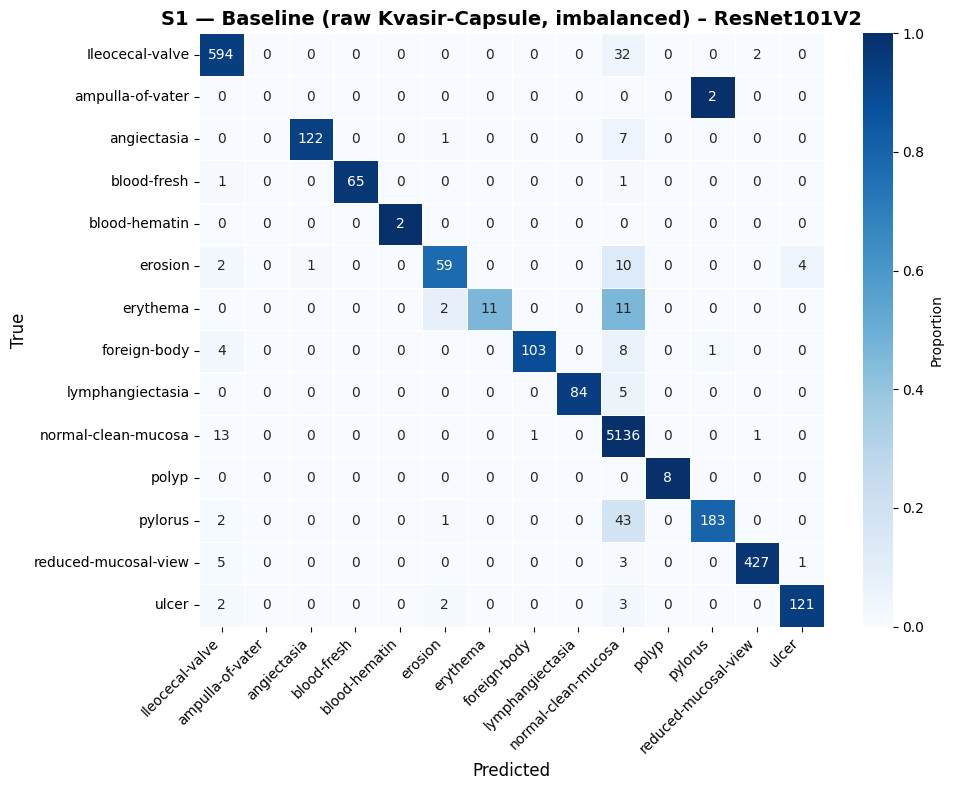

TF session cleared and garbage collected.


In [20]:
# ── S1 — Baseline (raw Kvasir-Capsule, imbalanced)  |  ResNet101V2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(capsule_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('ResNet101V2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s1_baseline/resnet101v2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s1_baseline_resnet101v2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – ResNet101V2',
    save_path='../outputs/s1_baseline/resnet101v2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)'] = all_results.get('S1 — Baseline (raw Kvasir-Capsule, imbalanced)', {})
all_results['S1 — Baseline (raw Kvasir-Capsule, imbalanced)']['ResNet101V2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S1 — Baseline (raw Kvasir-Capsule, imbalanced) – ResNet101V2',
    save_path='../outputs/s1_baseline/resnet101v2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


---
## S2 — Under-Sampling only (Kvasir-Capsule)


Dataset splits:
  Train:       1564 samples
  Validation:   336 samples
  Test:         336 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.0901 - loss: 4.0278
Epoch 1: val_loss improved from inf to 2.63706, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s2_undersample_efficientnetb0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 111s 677ms/step - accuracy: 0.0901 - loss: 4.0274 - val_accuracy: 0.0893 - val_loss: 2.6371 - learning_rate: 0.0010
Epoch 2/10
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0799 - loss: 3.4124
Epoch 2: val_loss improved from 2.63706 to 2.61816, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s2_undersample_efficientnetb0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0799 - loss: 3.4063 - val_accuracy: 0.0893 - val_loss: 2.6182 - learning_rate: 0.0010
Epoch 3/10
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0874 - loss: 2.9496
Epoch 

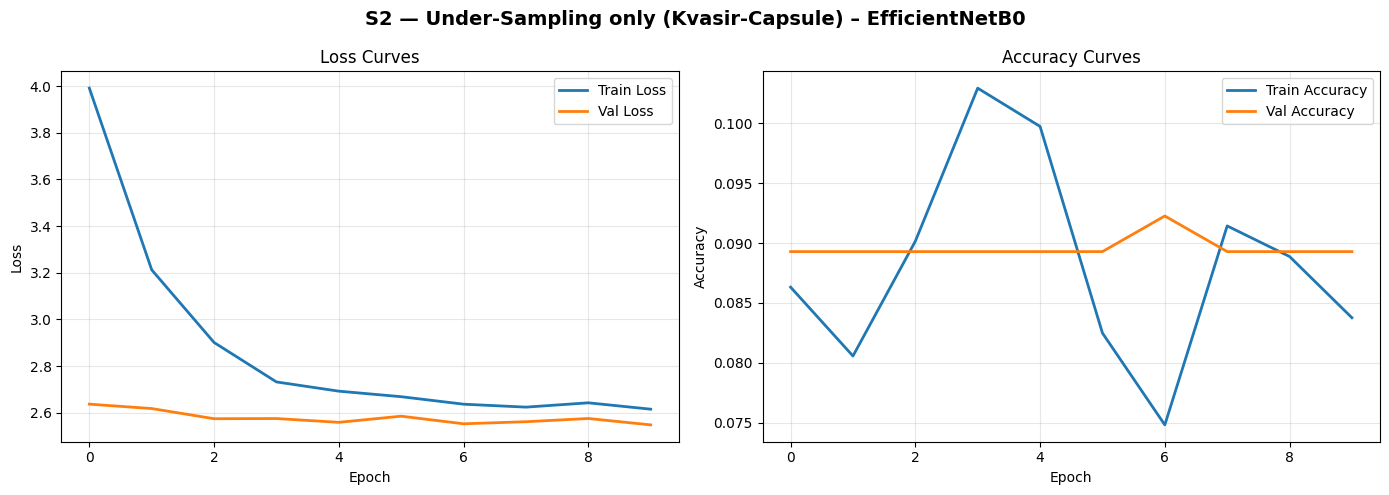


──────────────────────────────────────────────────
  EfficientNetB0 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.0893
  Precision: 0.0080
  Recall:    0.0893
  F1-score:  0.0146
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.00      0.00      0.00        30
    ampulla-of-vater       0.00      0.00      0.00         2
         angiectasia       0.00      0.00      0.00        30
         blood-fresh       0.09      1.00      0.16        30
       blood-hematin       0.00      0.00      0.00         2
             erosion       0.00      0.00      0.00        30
            erythema       0.00      0.00      0.00        24
        foreign-body       0.00      0.00      0.00        30
    lymphangiectasia       0.00      0.00      0.00        30
 normal-clean-mucosa       0.00      0.00      0.00        30
               polyp       0.00      0.00      0.00

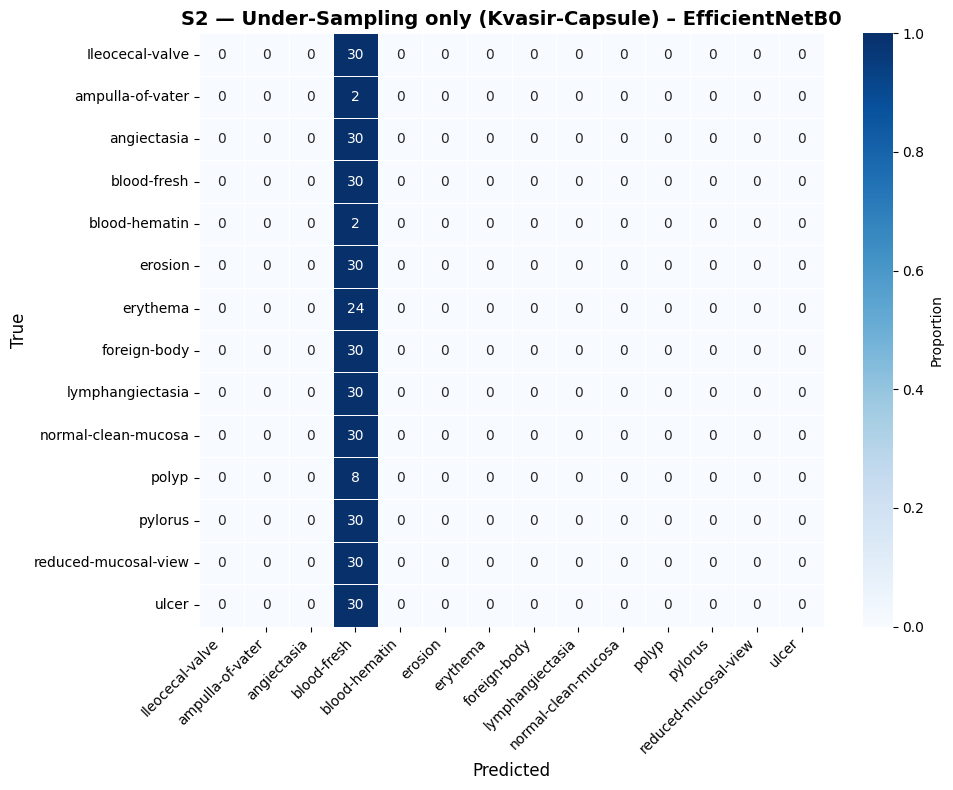

TF session cleared and garbage collected.


In [21]:
# ── S2 — Under-Sampling only (Kvasir-Capsule)  |  EfficientNetB0 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(undersampled)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('EfficientNetB0', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s2_undersample/efficientnetb0').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s2_undersample_efficientnetb0',
)

# 4. Plot history
plot_training_history(
    history,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – EfficientNetB0',
    save_path='../outputs/s2_undersample/efficientnetb0/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S2 — Under-Sampling only (Kvasir-Capsule)'] = all_results.get('S2 — Under-Sampling only (Kvasir-Capsule)', {})
all_results['S2 — Under-Sampling only (Kvasir-Capsule)']['EfficientNetB0'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – EfficientNetB0',
    save_path='../outputs/s2_undersample/efficientnetb0/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       1564 samples
  Validation:   336 samples
  Test:         336 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.3769 - loss: 2.5906
Epoch 1: val_loss improved from inf to 11.41428, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s2_undersample_mobilenetv2_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 432ms/step - accuracy: 0.3779 - loss: 2.5847 - val_accuracy: 0.0893 - val_loss: 11.4143 - learning_rate: 0.0010
Epoch 2/10
95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6542 - loss: 1.2577
Epoch 2: val_loss did not improve from 11.41428
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6542 - loss: 1.2565 - val_accuracy: 0.1131 - val_loss: 13.8117 - learning_rate: 0.0010
Epoch 3/10
95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7514 - loss: 0.9577
Epoch 3: val_loss improved from 11.41428 to 10.83431, saving model to /kaggle/working/DLMinorProject/outputs/checkpoint

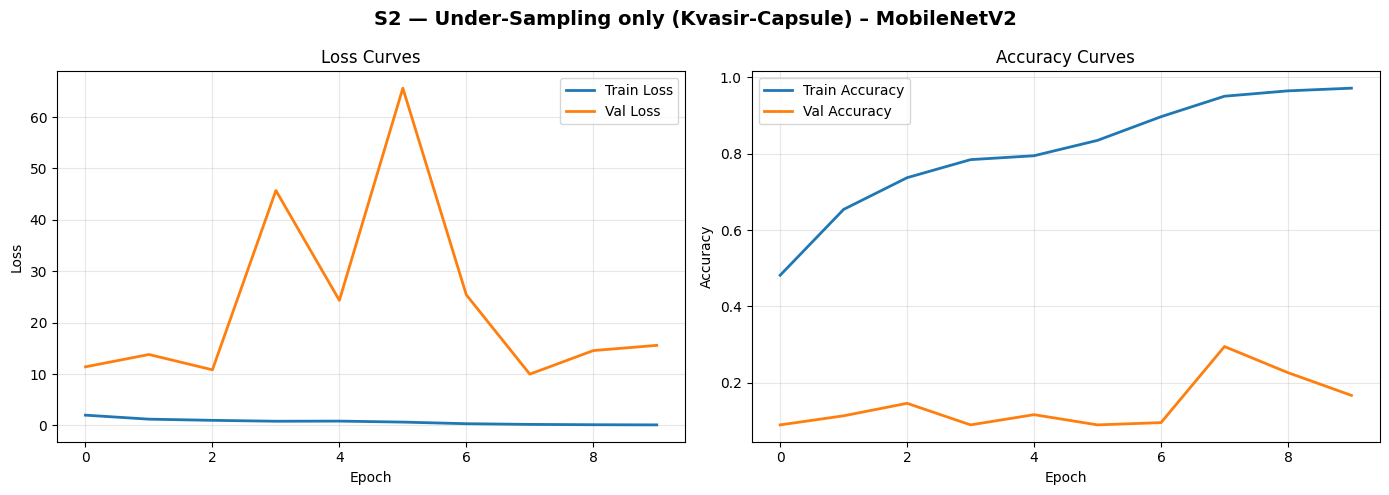


──────────────────────────────────────────────────
  MobileNetV2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.3185
  Precision: 0.2842
  Recall:    0.3185
  F1-score:  0.1963
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.00      0.00      0.00        30
    ampulla-of-vater       0.00      0.00      0.00         2
         angiectasia       0.24      0.83      0.37        30
         blood-fresh       0.38      0.87      0.53        30
       blood-hematin       0.00      0.00      0.00         2
             erosion       0.00      0.00      0.00        30
            erythema       0.00      0.00      0.00        24
        foreign-body       1.00      0.03      0.06        30
    lymphangiectasia       0.00      0.00      0.00        30
 normal-clean-mucosa       0.25      0.03      0.06        30
               polyp       1.00      0.38      0.55   

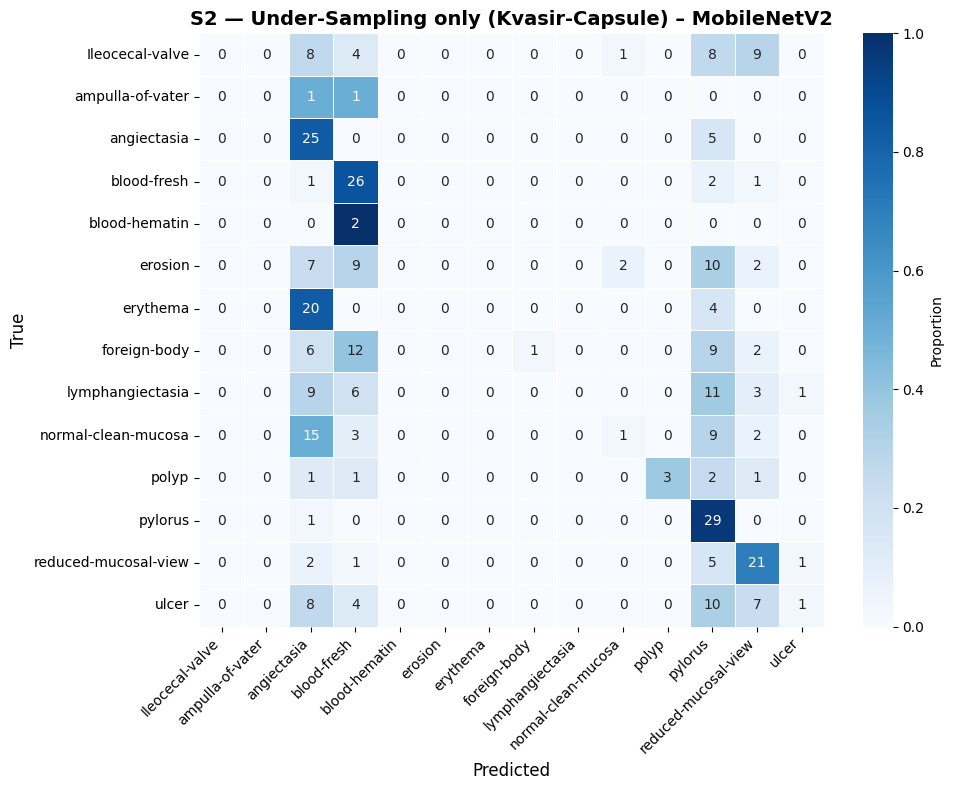

TF session cleared and garbage collected.


In [22]:
# ── S2 — Under-Sampling only (Kvasir-Capsule)  |  MobileNetV2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(undersampled)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('MobileNetV2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s2_undersample/mobilenetv2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s2_undersample_mobilenetv2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – MobileNetV2',
    save_path='../outputs/s2_undersample/mobilenetv2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S2 — Under-Sampling only (Kvasir-Capsule)'] = all_results.get('S2 — Under-Sampling only (Kvasir-Capsule)', {})
all_results['S2 — Under-Sampling only (Kvasir-Capsule)']['MobileNetV2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – MobileNetV2',
    save_path='../outputs/s2_undersample/mobilenetv2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       1564 samples
  Validation:   336 samples
  Test:         336 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.3917 - loss: 2.1598
Epoch 1: val_loss improved from inf to 8.08115, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s2_undersample_resnet101v2_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 464ms/step - accuracy: 0.3928 - loss: 2.1548 - val_accuracy: 0.1042 - val_loss: 8.0812 - learning_rate: 0.0010
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7828 - loss: 0.7414
Epoch 2: val_loss improved from 8.08115 to 1.34522, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s2_undersample_resnet101v2_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.7825 - loss: 0.7420 - val_accuracy: 0.6012 - val_loss: 1.3452 - learning_rate: 0.0010
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8211 - loss: 0.5901
Epoch 3: va

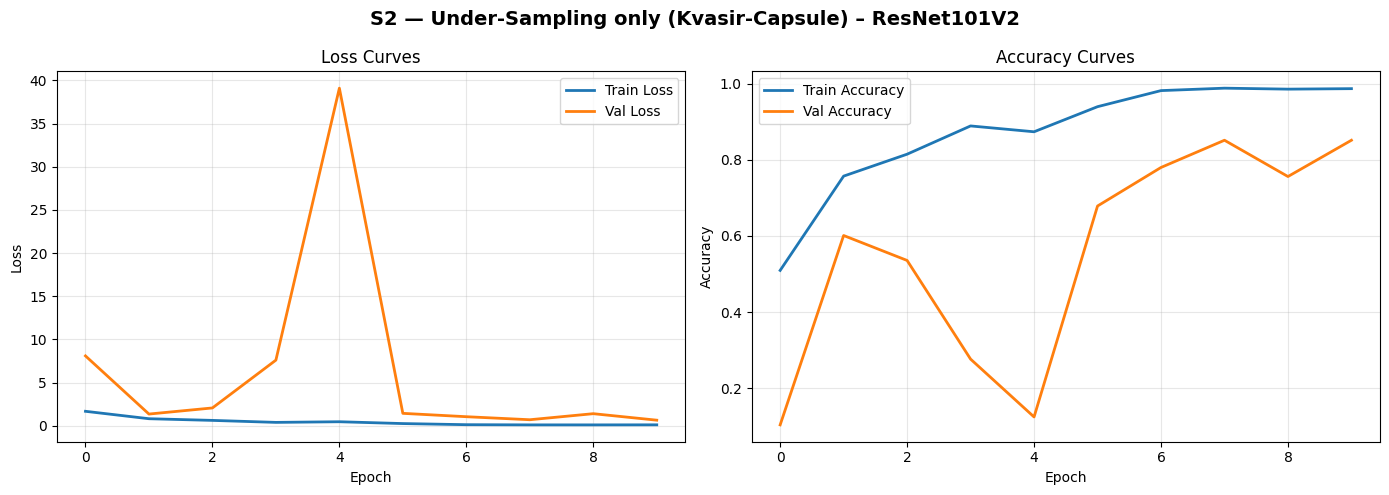


──────────────────────────────────────────────────
  ResNet101V2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.8214
  Precision: 0.8489
  Recall:    0.8214
  F1-score:  0.8237
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.63      0.87      0.73        30
    ampulla-of-vater       1.00      1.00      1.00         2
         angiectasia       1.00      0.93      0.97        30
         blood-fresh       1.00      0.87      0.93        30
       blood-hematin       1.00      1.00      1.00         2
             erosion       0.70      0.87      0.78        30
            erythema       0.94      0.67      0.78        24
        foreign-body       0.73      1.00      0.85        30
    lymphangiectasia       0.93      0.87      0.90        30
 normal-clean-mucosa       0.58      0.70      0.64        30
               polyp       1.00      1.00      1.00   

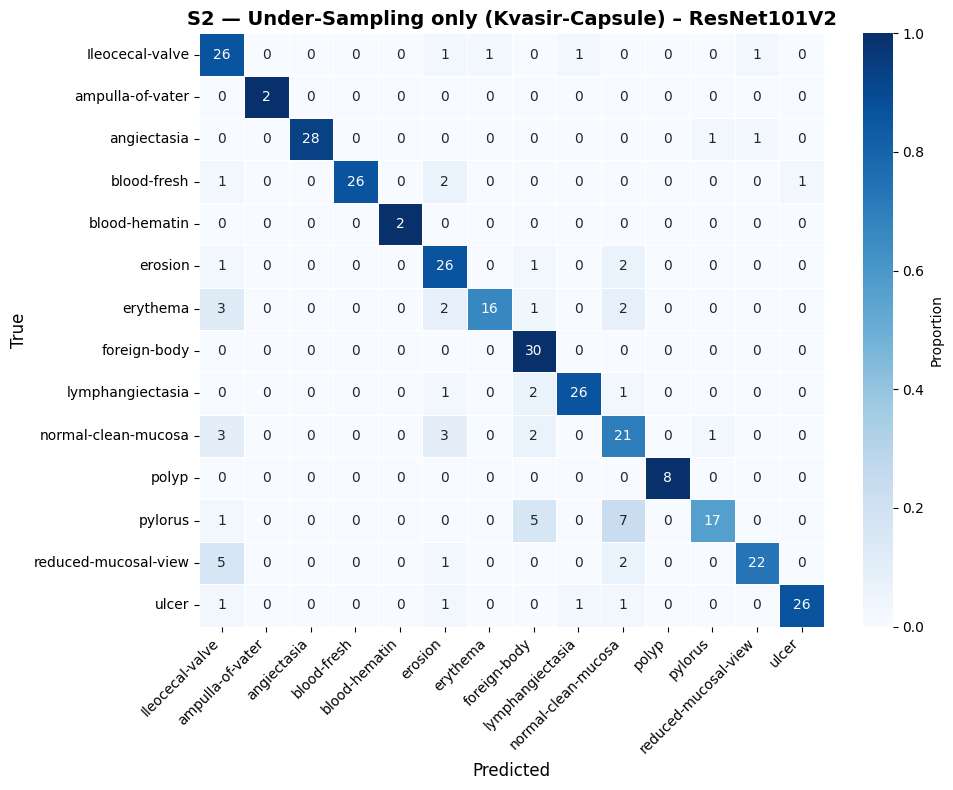

TF session cleared and garbage collected.


In [23]:
# ── S2 — Under-Sampling only (Kvasir-Capsule)  |  ResNet101V2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(undersampled)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('ResNet101V2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s2_undersample/resnet101v2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s2_undersample_resnet101v2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – ResNet101V2',
    save_path='../outputs/s2_undersample/resnet101v2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S2 — Under-Sampling only (Kvasir-Capsule)'] = all_results.get('S2 — Under-Sampling only (Kvasir-Capsule)', {})
all_results['S2 — Under-Sampling only (Kvasir-Capsule)']['ResNet101V2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S2 — Under-Sampling only (Kvasir-Capsule) – ResNet101V2',
    save_path='../outputs/s2_undersample/resnet101v2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


---
## S3 — Under-Sampling + Augmentation (Kvasir-Capsule)


Dataset splits:
  Train:       1960 samples
  Validation:   420 samples
  Test:         420 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.0656 - loss: 4.1095
Epoch 1: val_loss improved from inf to 2.84708, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s3_augmented_efficientnetb0_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 125s 689ms/step - accuracy: 0.0656 - loss: 4.1076 - val_accuracy: 0.0714 - val_loss: 2.8471 - learning_rate: 0.0010
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0701 - loss: 3.2346
Epoch 2: val_loss improved from 2.84708 to 2.73481, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s3_augmented_efficientnetb0_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0701 - loss: 3.2340 - val_accuracy: 0.0714 - val_loss: 2.7348 - learning_rate: 0.0010
Epoch 3/10
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0681 - loss: 2.9362


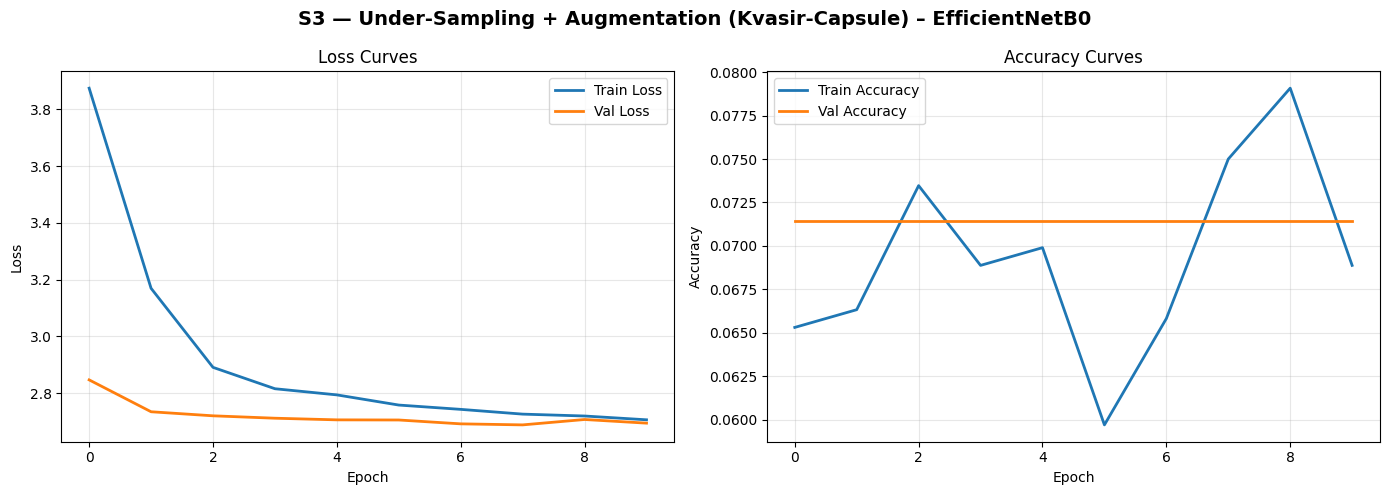


──────────────────────────────────────────────────
  EfficientNetB0 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.0714
  Precision: 0.0051
  Recall:    0.0714
  F1-score:  0.0095
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.00      0.00      0.00        30
    ampulla-of-vater       0.00      0.00      0.00        30
         angiectasia       0.00      0.00      0.00        30
         blood-fresh       0.00      0.00      0.00        30
       blood-hematin       0.07      1.00      0.13        30
             erosion       0.00      0.00      0.00        30
            erythema       0.00      0.00      0.00        30
        foreign-body       0.00      0.00      0.00        30
    lymphangiectasia       0.00      0.00      0.00        30
 normal-clean-mucosa       0.00      0.00      0.00        30
               polyp       0.00      0.00      0.00

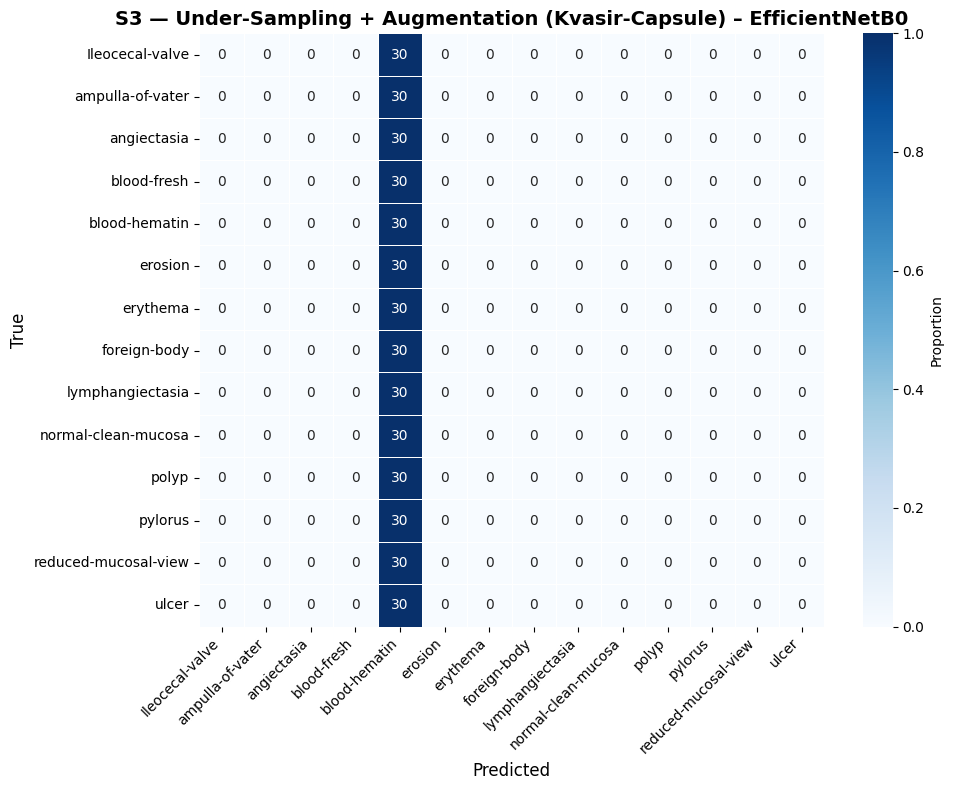

TF session cleared and garbage collected.


In [24]:
# ── S3 — Under-Sampling + Augmentation (Kvasir-Capsule)  |  EfficientNetB0 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(balanced)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('EfficientNetB0', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s3_augmented/efficientnetb0').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s3_augmented_efficientnetb0',
)

# 4. Plot history
plot_training_history(
    history,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – EfficientNetB0',
    save_path='../outputs/s3_augmented/efficientnetb0/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)'] = all_results.get('S3 — Under-Sampling + Augmentation (Kvasir-Capsule)', {})
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)']['EfficientNetB0'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – EfficientNetB0',
    save_path='../outputs/s3_augmented/efficientnetb0/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       1960 samples
  Validation:   420 samples
  Test:         420 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.4430 - loss: 2.2745
Epoch 1: val_loss improved from inf to 8.15919, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s3_augmented_mobilenetv2_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 84s 461ms/step - accuracy: 0.4439 - loss: 2.2703 - val_accuracy: 0.1619 - val_loss: 8.1592 - learning_rate: 0.0010
Epoch 2/10
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7008 - loss: 1.0532
Epoch 2: val_loss did not improve from 8.15919
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7011 - loss: 1.0533 - val_accuracy: 0.1095 - val_loss: 24.7104 - learning_rate: 0.0010
Epoch 3/10
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7773 - loss: 0.7993
Epoch 3: val_loss did not improve from 8.15919
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7775 - loss

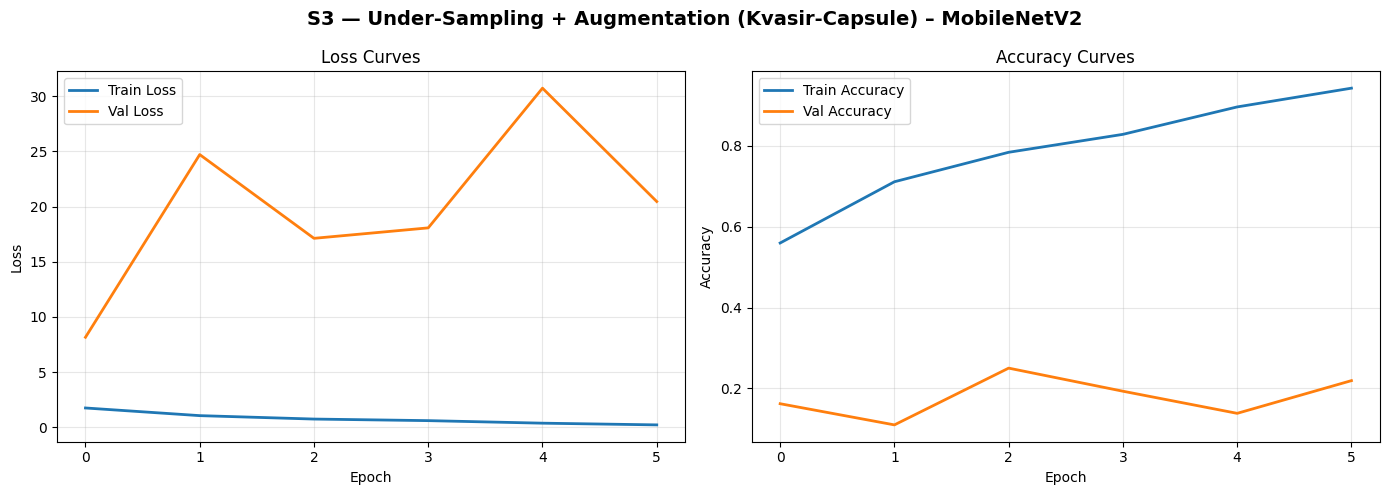


──────────────────────────────────────────────────
  MobileNetV2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.1643
  Precision: 0.1477
  Recall:    0.1643
  F1-score:  0.0754
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.15      0.90      0.25        30
    ampulla-of-vater       0.00      0.00      0.00        30
         angiectasia       0.00      0.00      0.00        30
         blood-fresh       0.79      0.37      0.50        30
       blood-hematin       0.00      0.00      0.00        30
             erosion       0.00      0.00      0.00        30
            erythema       1.00      0.03      0.06        30
        foreign-body       0.00      0.00      0.00        30
    lymphangiectasia       0.00      0.00      0.00        30
 normal-clean-mucosa       0.00      0.00      0.00        30
               polyp       0.14      1.00      0.24   

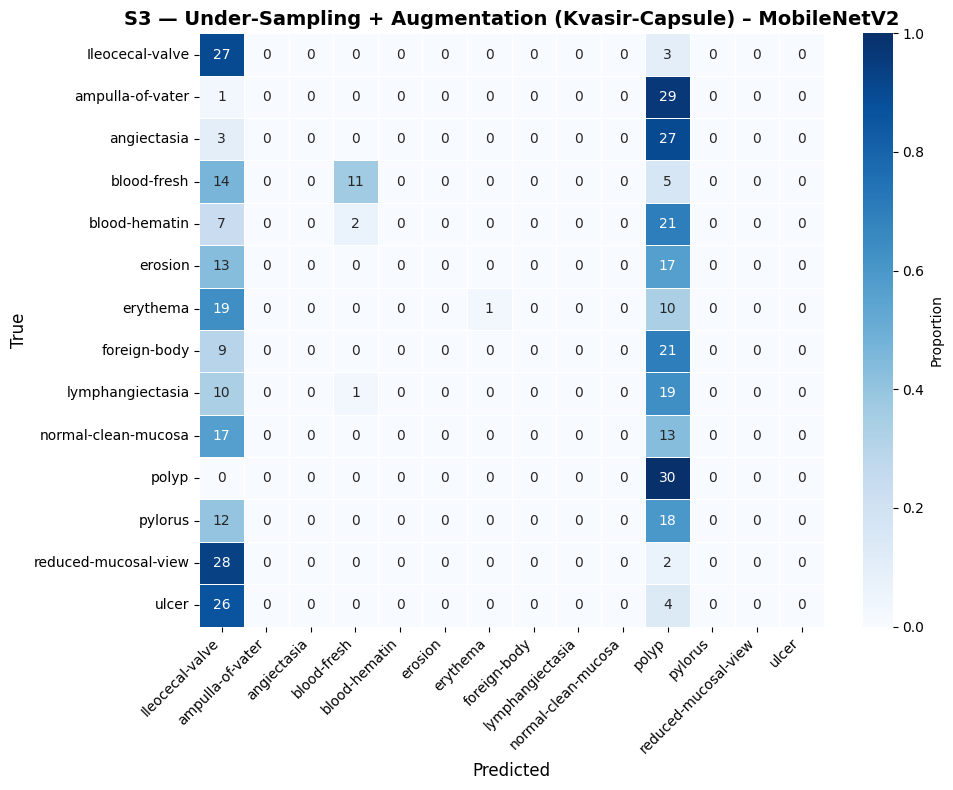

TF session cleared and garbage collected.


In [25]:
# ── S3 — Under-Sampling + Augmentation (Kvasir-Capsule)  |  MobileNetV2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(balanced)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('MobileNetV2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s3_augmented/mobilenetv2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s3_augmented_mobilenetv2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – MobileNetV2',
    save_path='../outputs/s3_augmented/mobilenetv2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)'] = all_results.get('S3 — Under-Sampling + Augmentation (Kvasir-Capsule)', {})
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)']['MobileNetV2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – MobileNetV2',
    save_path='../outputs/s3_augmented/mobilenetv2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       1960 samples
  Validation:   420 samples
  Test:         420 samples
  Classes:    14
  Image size: 224×224
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4658 - loss: 1.9188
Epoch 1: val_loss improved from inf to 3.00462, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s3_augmented_resnet101v2_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 90s 429ms/step - accuracy: 0.4667 - loss: 1.9154 - val_accuracy: 0.4714 - val_loss: 3.0046 - learning_rate: 0.0010
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7708 - loss: 0.7925
Epoch 2: val_loss improved from 3.00462 to 1.32863, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s3_augmented_resnet101v2_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.7707 - loss: 0.7928 - val_accuracy: 0.6167 - val_loss: 1.3286 - learning_rate: 0.0010
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8162 - loss: 0.6214
Epoch

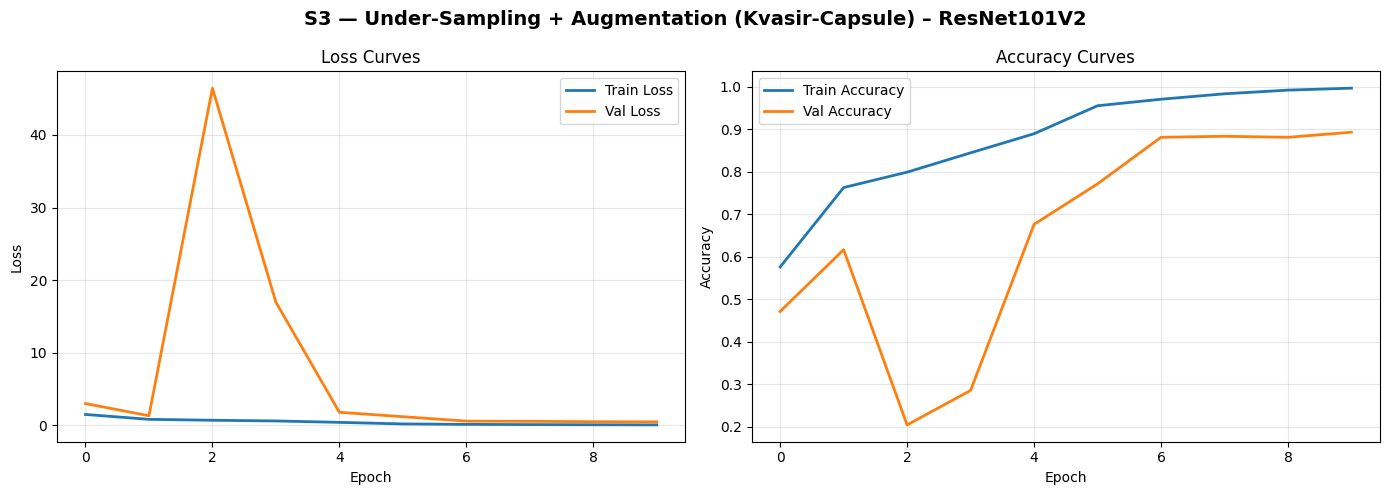


──────────────────────────────────────────────────
  ResNet101V2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.9310
  Precision: 0.9394
  Recall:    0.9310
  F1-score:  0.9311
──────────────────────────────────────────────────
                      precision    recall  f1-score   support

     Ileocecal-valve       0.89      0.80      0.84        30
    ampulla-of-vater       1.00      1.00      1.00        30
         angiectasia       1.00      1.00      1.00        30
         blood-fresh       0.91      1.00      0.95        30
       blood-hematin       1.00      1.00      1.00        30
             erosion       0.96      0.77      0.85        30
            erythema       0.97      0.97      0.97        30
        foreign-body       0.88      0.93      0.90        30
    lymphangiectasia       1.00      0.97      0.98        30
 normal-clean-mucosa       0.68      0.93      0.79        30
               polyp       1.00      1.00      1.00   

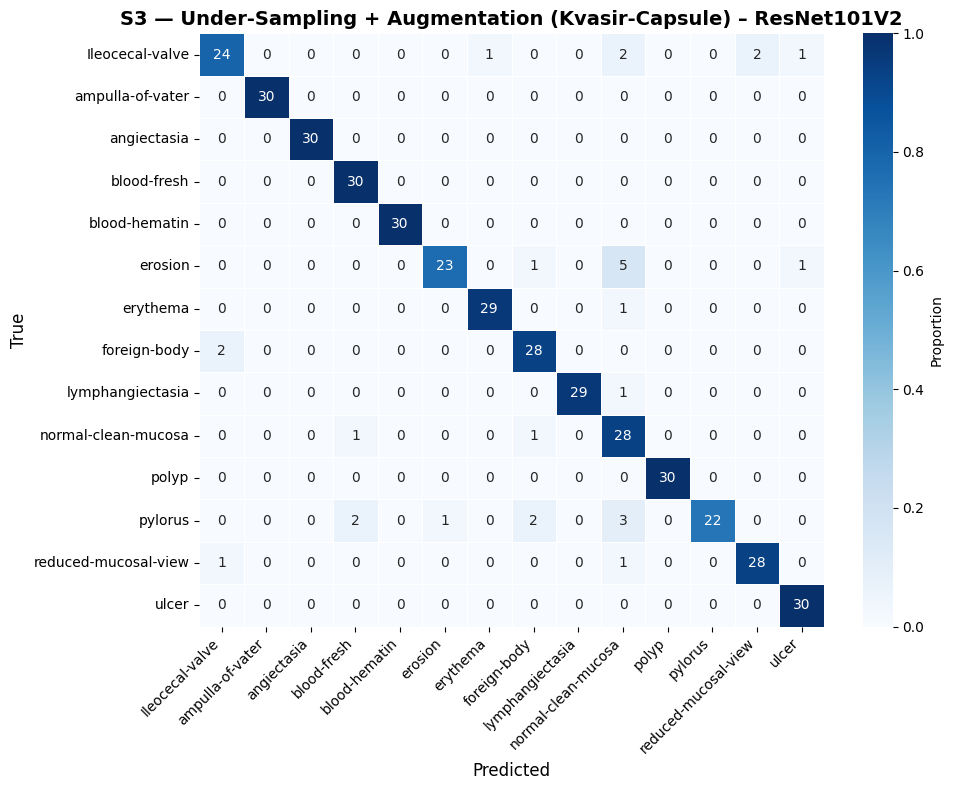

TF session cleared and garbage collected.


In [26]:
# ── S3 — Under-Sampling + Augmentation (Kvasir-Capsule)  |  ResNet101V2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(balanced)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('ResNet101V2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s3_augmented/resnet101v2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s3_augmented_resnet101v2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – ResNet101V2',
    save_path='../outputs/s3_augmented/resnet101v2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)'] = all_results.get('S3 — Under-Sampling + Augmentation (Kvasir-Capsule)', {})
all_results['S3 — Under-Sampling + Augmentation (Kvasir-Capsule)']['ResNet101V2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S3 — Under-Sampling + Augmentation (Kvasir-Capsule) – ResNet101V2',
    save_path='../outputs/s3_augmented/resnet101v2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


---
## S4 — Naturally Balanced (KVASIR v2)


Dataset splits:
  Train:       5600 samples
  Validation:  1200 samples
  Test:        1200 samples
  Classes:    8
  Image size: 224×224
Epoch 1/10
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1386 - loss: 3.2926
Epoch 1: val_loss improved from inf to 2.29041, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_efficientnetb0_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 103ms/step - accuracy: 0.1387 - loss: 3.2908 - val_accuracy: 0.1350 - val_loss: 2.2904 - learning_rate: 0.0010
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1771 - loss: 2.1550
Epoch 2: val_loss improved from 2.29041 to 1.92006, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_efficientnetb0_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.1771 - loss: 2.1548 - val_accuracy: 0.2008 - val_loss: 1.9201 - learning_rate: 0.0010
Epoch 3/10
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2062 - loss: 2.0041
Ep

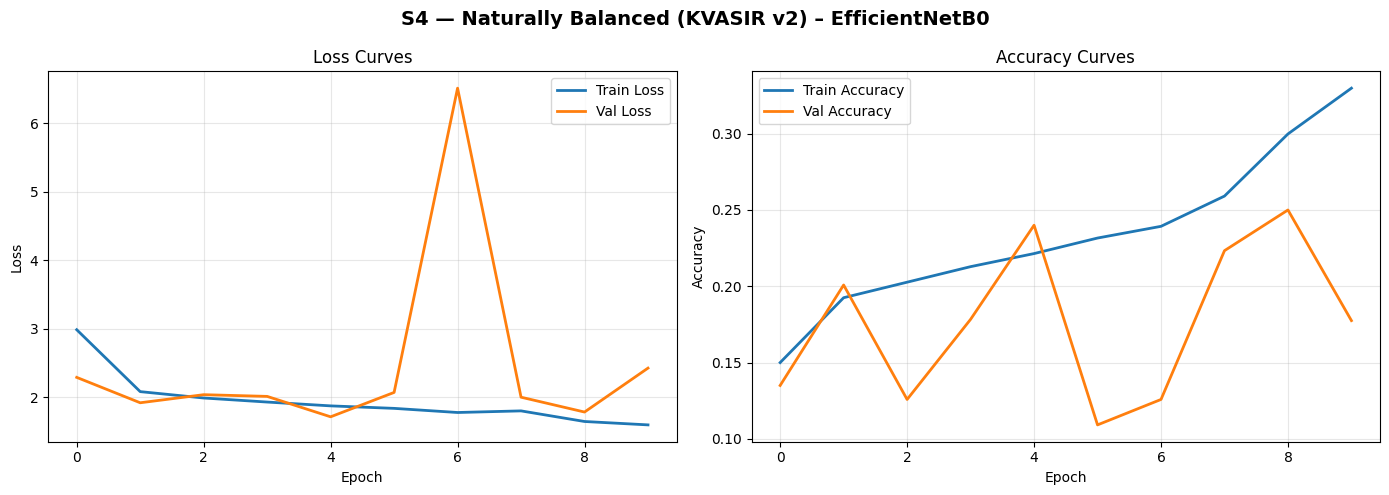


──────────────────────────────────────────────────
  EfficientNetB0 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.2492
  Precision: 0.1623
  Recall:    0.2492
  F1-score:  0.1602
──────────────────────────────────────────────────
                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.30      0.92      0.46       150
dyed-resection-margins       0.00      0.00      0.00       150
           esophagitis       0.41      0.05      0.08       150
          normal-cecum       0.00      0.00      0.00       150
        normal-pylorus       0.28      0.45      0.35       150
         normal-z-line       0.00      0.00      0.00       150
                polyps       0.28      0.54      0.37       150
    ulcerative-colitis       0.03      0.03      0.03       150

              accuracy                           0.25      1200
             macro avg       0.16      0.25      0.16      1200
          weighted avg      

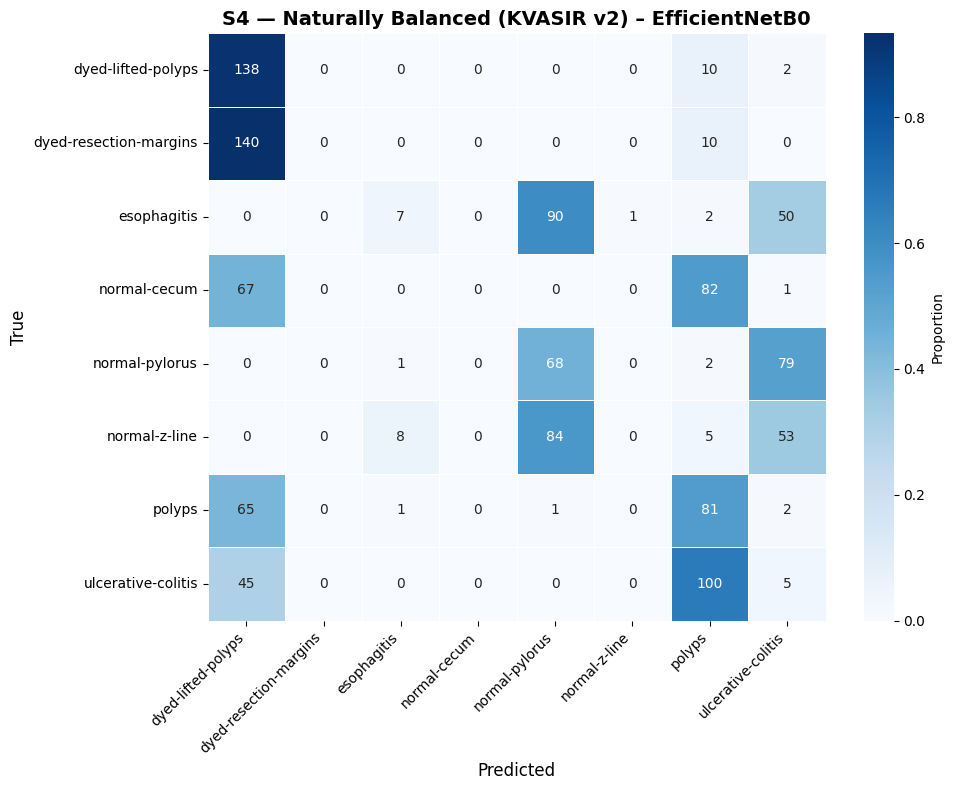

TF session cleared and garbage collected.


In [27]:
# ── S4 — Naturally Balanced (KVASIR v2)  |  EfficientNetB0 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(kvasir_v2_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('EfficientNetB0', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s4_kvasir_v2/efficientnetb0').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s4_kvasir_v2_efficientnetb0',
)

# 4. Plot history
plot_training_history(
    history,
    title='S4 — Naturally Balanced (KVASIR v2) – EfficientNetB0',
    save_path='../outputs/s4_kvasir_v2/efficientnetb0/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S4 — Naturally Balanced (KVASIR v2)'] = all_results.get('S4 — Naturally Balanced (KVASIR v2)', {})
all_results['S4 — Naturally Balanced (KVASIR v2)']['EfficientNetB0'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S4 — Naturally Balanced (KVASIR v2) – EfficientNetB0',
    save_path='../outputs/s4_kvasir_v2/efficientnetb0/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       5600 samples
  Validation:  1200 samples
  Test:        1200 samples
  Classes:    8
  Image size: 224×224
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6570 - loss: 1.2831
Epoch 1: val_loss improved from inf to 57.78216, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_mobilenetv2_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 91ms/step - accuracy: 0.6572 - loss: 1.2824 - val_accuracy: 0.1492 - val_loss: 57.7822 - learning_rate: 0.0010
Epoch 2/10
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8034 - loss: 0.6544
Epoch 2: val_loss improved from 57.78216 to 38.60171, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_mobilenetv2_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.8035 - loss: 0.6542 - val_accuracy: 0.4125 - val_loss: 38.6017 - learning_rate: 0.0010
Epoch 3/10
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8580 - loss: 0.4728
Epoc

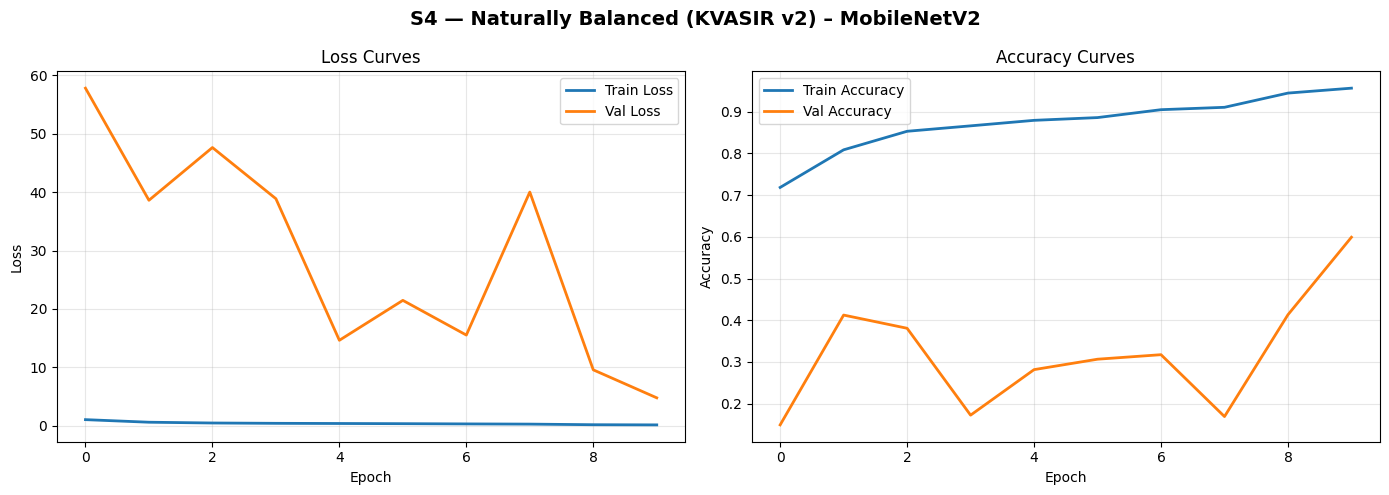


──────────────────────────────────────────────────
  MobileNetV2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.6067
  Precision: 0.6526
  Recall:    0.6067
  F1-score:  0.5541
──────────────────────────────────────────────────
                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.90      0.56      0.69       150
dyed-resection-margins       0.90      0.83      0.87       150
           esophagitis       0.61      0.79      0.69       150
          normal-cecum       0.38      1.00      0.55       150
        normal-pylorus       0.57      1.00      0.73       150
         normal-z-line       0.00      0.00      0.00       150
                polyps       0.86      0.52      0.65       150
    ulcerative-colitis       1.00      0.15      0.27       150

              accuracy                           0.61      1200
             macro avg       0.65      0.61      0.55      1200
          weighted avg       0.

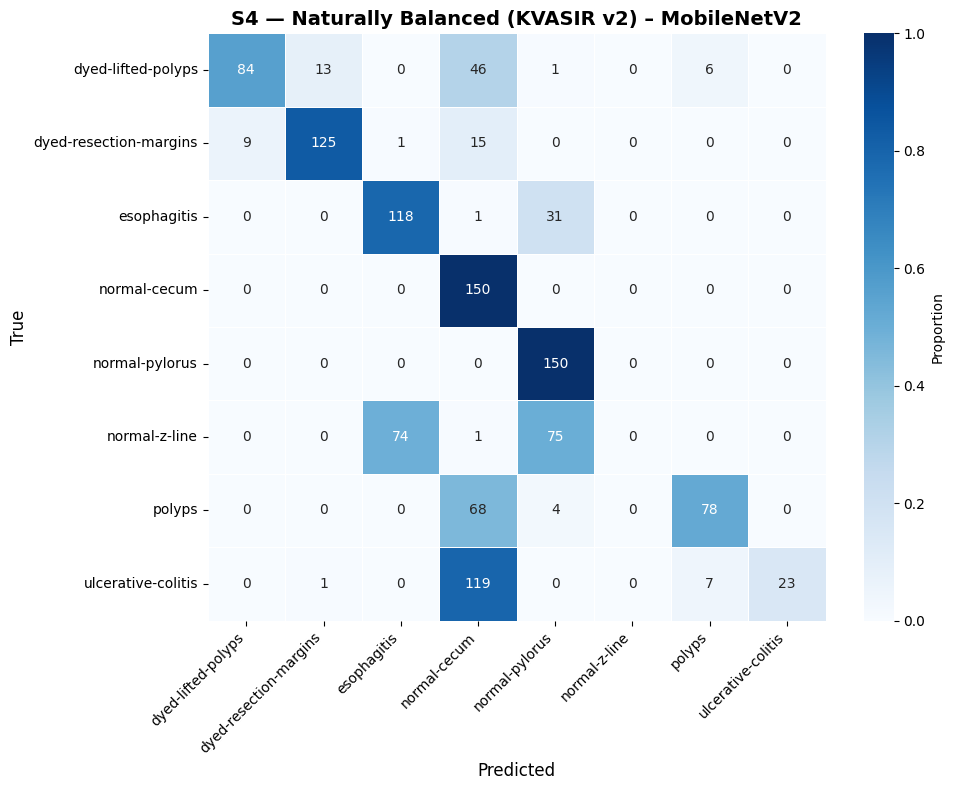

TF session cleared and garbage collected.


In [28]:
# ── S4 — Naturally Balanced (KVASIR v2)  |  MobileNetV2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(kvasir_v2_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('MobileNetV2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s4_kvasir_v2/mobilenetv2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s4_kvasir_v2_mobilenetv2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S4 — Naturally Balanced (KVASIR v2) – MobileNetV2',
    save_path='../outputs/s4_kvasir_v2/mobilenetv2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S4 — Naturally Balanced (KVASIR v2)'] = all_results.get('S4 — Naturally Balanced (KVASIR v2)', {})
all_results['S4 — Naturally Balanced (KVASIR v2)']['MobileNetV2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S4 — Naturally Balanced (KVASIR v2) – MobileNetV2',
    save_path='../outputs/s4_kvasir_v2/mobilenetv2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


Dataset splits:
  Train:       5600 samples
  Validation:  1200 samples
  Test:        1200 samples
  Classes:    8
  Image size: 224×224
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6554 - loss: 1.2205
Epoch 1: val_loss improved from inf to 29.07341, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_resnet101v2_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 81s 119ms/step - accuracy: 0.6556 - loss: 1.2199 - val_accuracy: 0.4550 - val_loss: 29.0734 - learning_rate: 0.0010
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7728 - loss: 0.8436
Epoch 2: val_loss improved from 29.07341 to 20.52536, saving model to /kaggle/working/DLMinorProject/outputs/checkpoints/s4_kvasir_v2_resnet101v2_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.7728 - loss: 0.8434 - val_accuracy: 0.4208 - val_loss: 20.5254 - learning_rate: 0.0010
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8250 - loss: 0.5678
Epo

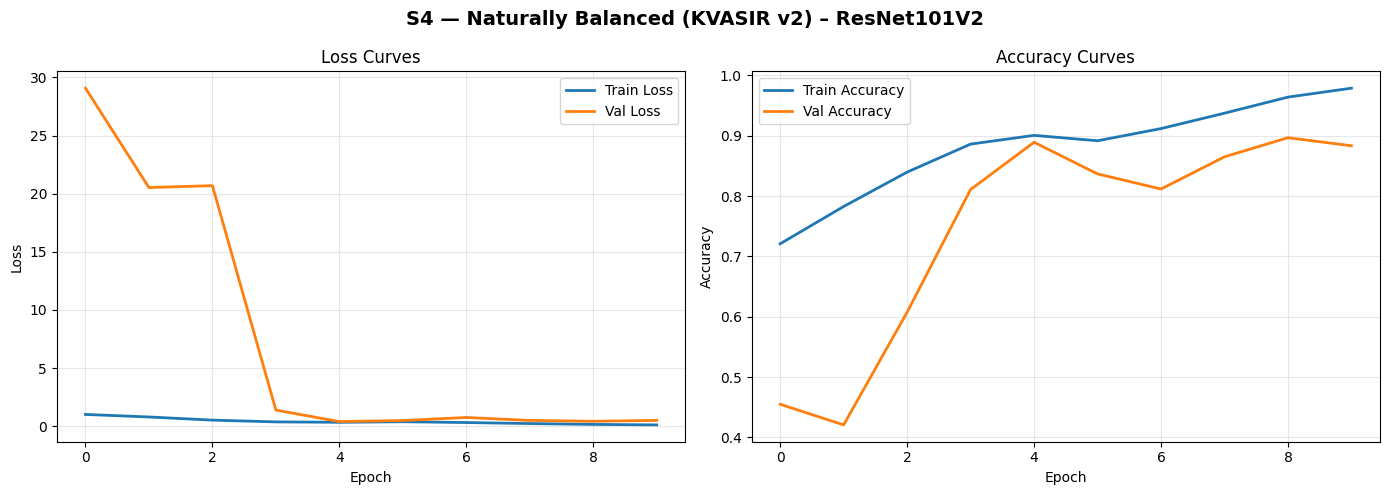


──────────────────────────────────────────────────
  ResNet101V2 — Test Results
──────────────────────────────────────────────────
  Accuracy:  0.8983
  Precision: 0.9145
  Recall:    0.8983
  F1-score:  0.8950
──────────────────────────────────────────────────
                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.93      0.91      0.92       150
dyed-resection-margins       0.94      0.93      0.93       150
           esophagitis       0.96      0.54      0.69       150
          normal-cecum       0.89      0.99      0.94       150
        normal-pylorus       0.97      1.00      0.99       150
         normal-z-line       0.68      0.98      0.81       150
                polyps       0.97      0.89      0.93       150
    ulcerative-colitis       0.97      0.94      0.95       150

              accuracy                           0.90      1200
             macro avg       0.91      0.90      0.90      1200
          weighted avg       0.

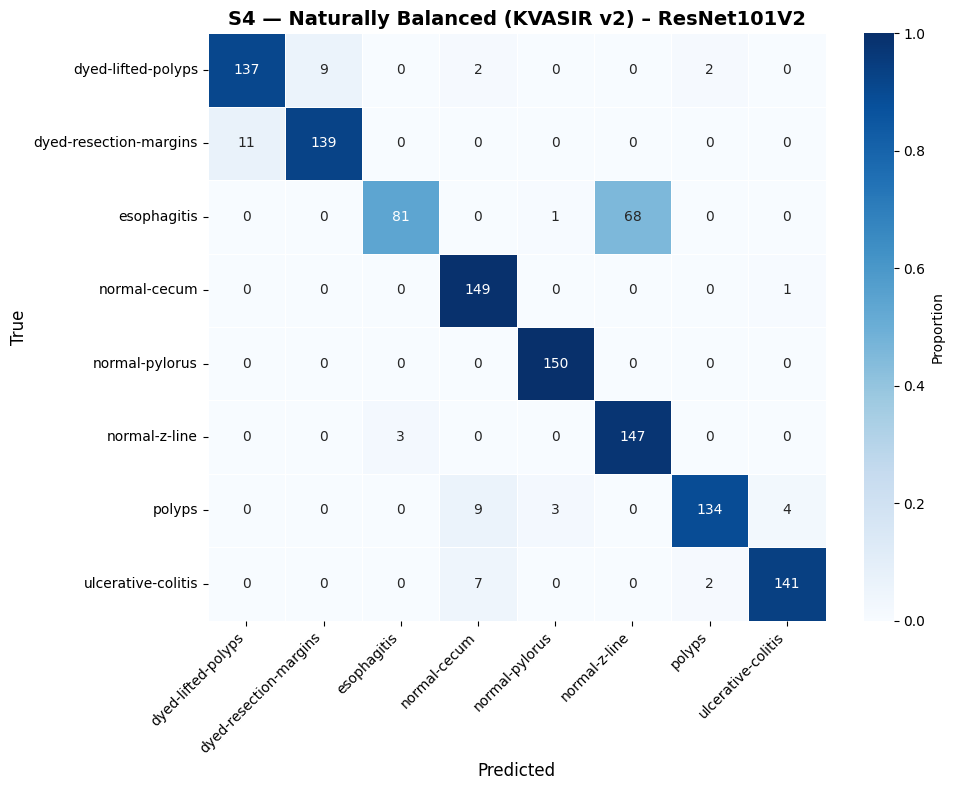

TF session cleared and garbage collected.


In [29]:
# ── S4 — Naturally Balanced (KVASIR v2)  |  ResNet101V2 ──
from src.training import clear_session

# 1. Split data
splits = preprocess_dataset(kvasir_v2_images)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
class_names      = splits['class_names']

# 2. Build & compile
model = build_model('ResNet101V2', num_classes=len(class_names))
compile_model(model)

# 3. Train
import pathlib
pathlib.Path('../outputs/s4_kvasir_v2/resnet101v2').mkdir(parents=True, exist_ok=True)
history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    epochs=10,
    save_name='s4_kvasir_v2_resnet101v2',
)

# 4. Plot history
plot_training_history(
    history,
    title='S4 — Naturally Balanced (KVASIR v2) – ResNet101V2',
    save_path='../outputs/s4_kvasir_v2/resnet101v2/history.png',
)

# 5. Evaluate
metrics = evaluate_model(model, X_test, y_test, class_names)
all_results['S4 — Naturally Balanced (KVASIR v2)'] = all_results.get('S4 — Naturally Balanced (KVASIR v2)', {})
all_results['S4 — Naturally Balanced (KVASIR v2)']['ResNet101V2'] = metrics

# 6. Confusion matrix
plot_confusion_matrix(
    y_test, metrics['y_pred'], class_names,
    title='S4 — Naturally Balanced (KVASIR v2) – ResNet101V2',
    save_path='../outputs/s4_kvasir_v2/resnet101v2/confusion.png',
)

# 7. Free RAM
del model, history, splits, X_train, X_val, X_test, y_train, y_val, y_test
clear_session()


---
## Comparison


In [30]:
# ── Final comparison across all scenarios & models ──
# all_results shape: {setting: {arch: metrics_dict}} — matches build_comparison_table
display_comparison(build_comparison_table(all_results))



                                                                    Accuracy  Precision    Recall  F1-Score
Setting                                             Model                                                  
S1 — Baseline (raw Kvasir-Capsule, imbalanced)      EfficientNetB0  0.726926   0.528422  0.726926  0.611980
                                                    MobileNetV2     0.787468   0.816967  0.787468  0.760722
                                                    ResNet101V2     0.975868   0.975627  0.975868  0.974888
S2 — Under-Sampling only (Kvasir-Capsule)           EfficientNetB0  0.089286   0.007972  0.089286  0.014637
                                                    MobileNetV2     0.318452   0.284245  0.318452  0.196347
                                                    ResNet101V2     0.821429   0.848908  0.821429  0.823746
S3 — Under-Sampling + Augmentation (Kvasir-Capsule) EfficientNetB0  0.071429   0.005102  0.071429  0.009524
                           